# SmileGuard — Dental Detection Training Pipeline

## Pipeline Overview
1. **Download** — Kaggle 6-Class Intraoral Disease Dataset
2. **Convert** — DatasetNinja annotations → YOLO format
3. **Convert** — Kaggle classification images → YOLO format (full-image bboxes)
4. **Merge** — Combine both datasets into one unified set
5. **Validate** — Verify all files are in place, check class mappings
6. **Balance Check** — Analyze class distribution & detect over/under-sampling
7. **Train** — YOLOv8 model training
8. **Evaluate** — Model performance metrics
9. **Inference** — DentalDetector class + visualization
10. **API** — Flask endpoint for integration

## Step 1 — Download Kaggle Dataset
Download the [6-Class Intraoral Disease Dataset](https://www.kaggle.com/datasets/sehrishnoords/6-class-intraoral-disease-dataset) (classification: Calculus, Caries, Gingivitis, Hypodontia, Mouth Ulcer, Tooth Discoloration).

In [7]:
# Paths to both datasets
from pathlib import Path
dental_roboflow = Path('./Dental-Dataset-roboflow')
roboflow_dataset = Path('./Roboflow-dataset')
dental_mates = Path('./Dental_Mates')

# Read class names from both data.yaml files
import yaml
with open(dental_roboflow / 'data.yaml') as f:
    dental_classes = yaml.safe_load(f)['names']
with open(roboflow_dataset / 'data.yaml') as f:
    roboflow_classes = yaml.safe_load(f)['names']
with open(dental_mates / 'data.yaml') as f:
    mates_classes = yaml.safe_load(f)['names']
print('Dental-Dataset-roboflow classes:', dental_classes)
print('Roboflow-dataset classes:', roboflow_classes)
print('Dental_Mates classes:', mates_classes)

# Harmonize class names (example: unify capitalization, spelling, etc.)
def normalize_class(name):
    return name.strip().lower().replace(' ', '_')

dental_classes_norm = [normalize_class(c) for c in dental_classes]
roboflow_classes_norm = [normalize_class(c) for c in roboflow_classes]
mates_classes_norm = [normalize_class(c) for c in mates_classes]

print('Normalized Dental-Dataset-roboflow:', dental_classes_norm)
print('Normalized Roboflow-dataset:', roboflow_classes_norm)
print('Normalized Dental_Mates_Dataset:', mates_classes_norm)

# Check for congruence
if set(dental_classes_norm).issubset(set(roboflow_classes_norm)) or set(roboflow_classes_norm).issubset(set(dental_classes_norm)) or set(mates_classes_norm).issubset(set(dental_classes_norm)) or set(mates_classes_norm).issubset(set(mates_classes_norm)):
    print('Datasets are congruent or can be merged directly.')
else:
    print('Datasets have different classes. Manual mapping or merging required.')

Dental-Dataset-roboflow classes: ['Braces', 'Caries', 'Cavity', 'Misaligned tooth', 'Plaque', 'crown']
Roboflow-dataset classes: ['Caries', 'Cavity', 'Crack', 'Tooth']
Dental_Mates classes: ['Caries', 'Cavity', 'Crack', 'Tooth']
Normalized Dental-Dataset-roboflow: ['braces', 'caries', 'cavity', 'misaligned_tooth', 'plaque', 'crown']
Normalized Roboflow-dataset: ['caries', 'cavity', 'crack', 'tooth']
Normalized Dental_Mates_Dataset: ['caries', 'cavity', 'crack', 'tooth']
Datasets are congruent or can be merged directly.


In [ ]:
# Run merge_and_trim.py to merge and trim Roboflow data
import subprocess
subprocess.run(['python', 'merge_and_trim_roboflow.py'], check=True)

CompletedProcess(args=['python', 'merge_and_trim.py'], returncode=0)

In [ ]:
# Run merge_and_trim.py to merge and trim Roboflow2 data
import subprocess
subprocess.run(['python', 'merge_and_trim_roboflow2.py'], check=True)

CompletedProcess(args=['python', 'merge_and_trim_roboflow2.py'], returncode=0)

In [35]:
# Run merge_and_trim.py to merge and trim Dental_Mates data
import subprocess
subprocess.run(['python', 'merge_and_trim_mates.py'], check=True)

CompletedProcess(args=['python', 'merge_and_trim_mates.py'], returncode=0)

In [1]:
# Run merge_and_trim.py to merge and trim Dental_Teeth data
import subprocess
subprocess.run(['python', 'merge_and_trim_teeth.py'], check=True)

CompletedProcess(args=['python', 'merge_and_trim_teeth.py'], returncode=0)

### Remove Small Classes
Run the remove_small_classes.py script to filter out classes with too few samples from the merged dataset.

In [2]:
# Run remove_small_classes.py to filter out small classes
import subprocess
subprocess.run(['python', 'remove_small_classes.py'], check=True)

CompletedProcess(args=['python', 'remove_small_classes.py'], returncode=0)

# SmileGuard — Dental Detection Training Pipeline

## Pipeline Overview
1. **Download** — Kaggle 6-Class Intraoral Disease Dataset
2. **Convert** — DatasetNinja annotations → YOLO format
3. **Convert** — Kaggle classification images → YOLO format (full-image bboxes)
4. **Merge** — Combine both datasets into one unified set
5. **Validate** — Verify all files are in place, check class mappings
6. **Balance Check** — Analyze class distribution & detect over/under-sampling
7. **Train** — YOLOv8 model training
8. **Evaluate** — Model performance metrics
9. **Inference** — DentalDetector class + visualization
10. **API** — Flask endpoint for integration

## Step 1 — Download Kaggle Dataset
Download the [6-Class Intraoral Disease Dataset](https://www.kaggle.com/datasets/sehrishnoords/6-class-intraoral-disease-dataset) (classification: Calculus, Caries, Gingivitis, Hypodontia, Mouth Ulcer, Tooth Discoloration).

In [ ]:
%pip install kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import kagglehub
from pathlib import Path

# Download the 6-class intraoral disease dataset
kaggle_path = kagglehub.dataset_download("sehrishnoords/6-class-intraoral-disease-dataset")
KAGGLE_ROOT = Path(kaggle_path) / "6_classs_Intraoral_dental_disease"

print(f"✅ Downloaded to: {kaggle_path}")
print(f"   Disease folder: {KAGGLE_ROOT}")

# Quick summary
import os
for d in sorted(KAGGLE_ROOT.iterdir()):
    if d.is_dir():
        count = len([f for f in d.iterdir() if f.is_file()])
        print(f"   {d.name:<25} {count:>5} images")

✅ Downloaded to: C:\Users\nangi\.cache\kagglehub\datasets\sehrishnoords\6-class-intraoral-disease-dataset\versions\1
   Disease folder: C:\Users\nangi\.cache\kagglehub\datasets\sehrishnoords\6-class-intraoral-disease-dataset\versions\1\6_classs_Intraoral_dental_disease
   Calculus                   1512 images
   caries                     2601 images
   Gingivitis                 2349 images
   hypodontia                 1515 images
   mouth ulcer                2806 images
   tooth_discoloration        2017 images


## Step 2 — Convert DatasetNinja → YOLO Format
Convert the `dentalai-DatasetNinja` annotations (JSON polygon format) into YOLO bounding-box labels.
Classes: `tooth`(0), `caries`(1), `cavity`(2), `crack`(3)

In [23]:
import shutil, os, json
from pathlib import Path

SRC_DIR  = Path("./dentalai-DatasetNinja")
DEST_DIR = Path("./yolo_dataset")

classes = {'tooth': 0, 'Tooth': 0, 'caries': 1, 'Caries': 1,
           'cavity': 2, 'Cavity': 2, 'crack': 3, 'Crack': 3}
CLASS_NAMES = ['tooth', 'caries', 'cavity', 'crack']

# Setup directories
for split in ['train', 'val', 'test']:
    (DEST_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (DEST_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

# Write data.yaml with absolute paths
DEST_ABS = str(DEST_DIR.resolve())
yaml_content = f"""train: {DEST_ABS}/train/images
val: {DEST_ABS}/val/images
test: {DEST_ABS}/test/images

nc: {len(CLASS_NAMES)}
names: {CLASS_NAMES}
"""
(DEST_DIR / "data.yaml").write_text(yaml_content)

# Convert
dirs_map = {"train": "train", "valid": "val", "test": "test"}
total_converted = 0
skipped_labels = set()

for src_folder, dest_folder in dirs_map.items():
    src_img = SRC_DIR / src_folder / "img"
    src_ann = SRC_DIR / src_folder / "ann"
    if not src_img.exists():
        print(f"⚠️  Skipping '{src_folder}' — not found")
        continue

    json_files = [f for f in os.listdir(src_ann) if f.endswith('.json')]
    print(f"Processing {src_folder}: {len(json_files)} annotations...")

    for jf in json_files:
        with open(src_ann / jf) as f:
            data = json.load(f)
        img_h, img_w = data['size']['height'], data['size']['width']
        yolo_lines = []
        for obj in data['objects']:
            label = obj['classTitle']
            if label not in classes:
                skipped_labels.add(label)
                continue
            cid = classes[label]
            pts = obj['points']['exterior']
            xs, ys = [p[0] for p in pts], [p[1] for p in pts]
            x_min, x_max = max(0, min(xs)), min(img_w, max(xs))
            y_min, y_max = max(0, min(ys)), min(img_h, max(ys))
            bw, bh = x_max - x_min, y_max - y_min
            if bw <= 0 or bh <= 0:
                continue
            xc, yc = x_min + bw/2, y_min + bh/2
            yolo_lines.append(f"{cid} {xc/img_w:.6f} {yc/img_h:.6f} {bw/img_w:.6f} {bh/img_h:.6f}")

        if yolo_lines:
            stem = Path(jf).stem            # "image.jpg" from "image.jpg.json"
            img_name = stem                  # image filename
            lbl_stem = Path(stem).stem       # "image" from "image.jpg"
            (DEST_DIR / dest_folder / "labels" / f"{lbl_stem}.txt").write_text("\n".join(yolo_lines))
            img_src = src_img / img_name
            if img_src.exists():
                shutil.copy(img_src, DEST_DIR / dest_folder / "images" / img_name)
                total_converted += 1

if skipped_labels:
    print(f"⚠️  Skipped unknown labels: {skipped_labels}")
print(f"\n✅ DatasetNinja → YOLO: {total_converted} images converted to {DEST_DIR}")

Processing train: 1991 annotations...
Processing valid: 254 annotations...
Processing test: 250 annotations...

✅ DatasetNinja → YOLO: 2495 images converted to yolo_dataset


## Step 3 — Convert Kaggle Classification → YOLO Format
The Kaggle dataset is **classification-only** (folder-per-class, no bounding boxes). We convert it to YOLO detection format using **full-image bounding boxes** (`0.5 0.5 1.0 1.0`).

**Class mapping** — only `caries` overlaps with the existing dataset; other Kaggle classes are added as new disease types:

| Kaggle Class | → Unified ID | Note |
|---|---|---|
| caries | 1 | Overlaps with DatasetNinja |
| Calculus | 4 | New |
| Gingivitis | 5 | New |
| hypodontia | 6 | New |
| mouth ulcer | 7 | New |
| tooth discoloration | 8 | New |

In [ ]:
import shutil, random
from pathlib import Path

# ── Config ───────────────────────────────────────────────────────────────
KAGGLE_ROOT = Path(r"C:\Users\nangi\.cache\kagglehub\datasets\sehrishnoords\6-class-intraoral-disease-dataset\versions\1\6_classs_Intraoral_dental_disease")
KAGGLE_YOLO = Path("./kaggle_yolo")       # Intermediate YOLO-format output
VALID_EXTS  = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Map Kaggle folder names → unified class IDs
# IDs 0-3 match the existing DatasetNinja classes
KAGGLE_CLASS_MAP = {
    "caries":              1,   # overlaps with existing
    "Calculus":            4,   # new
    "Gingivitis":          5,   # new
    "hypodontia":          6,   # new
    "mouth ulcer":         7,   # new
    "tooth_discoloration": 8,   # new
}

SPLIT_RATIOS = {"train": 0.80, "val": 0.15, "test": 0.05}

# ── Setup output dirs ────────────────────────────────────────────────────
for split in SPLIT_RATIOS:
    (KAGGLE_YOLO / split / "images").mkdir(parents=True, exist_ok=True)
    (KAGGLE_YOLO / split / "labels").mkdir(parents=True, exist_ok=True)

# ── Convert each class folder ────────────────────────────────────────────
random.seed(42)
stats = {}

for folder_name, class_id in KAGGLE_CLASS_MAP.items():
    cls_dir = KAGGLE_ROOT / folder_name
    if not cls_dir.exists():
        print(f"⚠️  Folder not found: {cls_dir}")
        continue

    images = [f for f in cls_dir.iterdir() if f.is_file() and f.suffix.lower() in VALID_EXTS]
    random.shuffle(images)

    n = len(images)
    n_train = int(n * SPLIT_RATIOS["train"])
    n_val   = int(n * SPLIT_RATIOS["val"])

    splits = {
        "train": images[:n_train],
        "val":   images[n_train:n_train + n_val],
        "test":  images[n_train + n_val:],
    }

    split_counts = {}
    for split_name, split_imgs in splits.items():
        for i, img_path in enumerate(split_imgs):
            # Unique name to avoid collisions
            new_stem = f"kaggle_{folder_name.replace(' ', '_')}_{i:04d}"
            new_ext  = img_path.suffix.lower()

            # Copy image
            shutil.copy(img_path, KAGGLE_YOLO / split_name / "images" / f"{new_stem}{new_ext}")

            # Write full-image bbox label: class_id 0.5 0.5 1.0 1.0
            (KAGGLE_YOLO / split_name / "labels" / f"{new_stem}.txt").write_text(
                f"{class_id} 0.500000 0.500000 1.000000 1.000000"
            )

        split_counts[split_name] = len(split_imgs)

    stats[folder_name] = {"id": class_id, "total": n, **split_counts}
    print(f"  ✅ {folder_name:<25} → class {class_id}  |  train={split_counts['train']}  val={split_counts['val']}  test={split_counts['test']}")

print(f"\n✅ Kaggle → YOLO: {sum(s['total'] for s in stats.values())} images converted to {KAGGLE_YOLO}")

  ✅ caries                    → class 1  |  train=2080  val=390  test=131
  ✅ Calculus                  → class 4  |  train=1209  val=226  test=77
  ✅ Gingivitis                → class 5  |  train=1879  val=352  test=118
  ✅ hypodontia                → class 6  |  train=1212  val=227  test=76
  ✅ mouth ulcer               → class 7  |  train=2244  val=420  test=142
  ✅ tooth_discoloration       → class 8  |  train=1613  val=302  test=102

✅ Kaggle → YOLO: 12800 images converted to kaggle_yolo


## Step 4 — Merge Datasets
Merge the two YOLO datasets (`yolo_dataset` from DatasetNinja + `kaggle_yolo` from Kaggle) into a single unified `yolo_dataset_merged/` with 9 classes.

In [15]:
import shutil, os
from pathlib import Path

# ── Config ───────────────────────────────────────────────────────────────
OUTPUT_DIR = Path("./yolo_dataset_merged")

UNIFIED_NAMES = [
    'tooth',               # 0 — from DatasetNinja
    'caries',              # 1 — from both
    'cavity',              # 2 — from DatasetNinja
    'crack',               # 3 — from DatasetNinja
    'calculus',            # 4 — from Kaggle
    'gingivitis',          # 5 — from Kaggle
    'hypodontia',          # 6 — from Kaggle
    'mouth_ulcer',         # 7 — from Kaggle
    'tooth_discoloration', # 8 — from Kaggle
]

DATASET_SOURCES = [
    {"path": Path("./yolo_dataset"),  "remap": None},   # Already uses IDs 0-3
    {"path": Path("./kaggle_yolo"),   "remap": None},   # Already uses IDs 1,4-8
]

# ── Setup output ─────────────────────────────────────────────────────────
for split in ['train', 'val', 'test']:
    (OUTPUT_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / split / "labels").mkdir(parents=True, exist_ok=True)

# ── Merge loop ───────────────────────────────────────────────────────────
global_idx = 0

for ds in DATASET_SOURCES:
    ds_path = ds["path"]
    if not ds_path.exists():
        print(f"⚠️  Not found: {ds_path} — skipping")
        continue

    print(f"\n📂 Merging: {ds_path}")
    ds_count = 0

    for split_src in ['train', 'val', 'test']:
        img_dir = ds_path / split_src / "images"
        lbl_dir = ds_path / split_src / "labels"
        if not img_dir.exists():
            continue

        images = sorted(img_dir.glob("*"))
        for img_path in images:
            if img_path.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
                continue

            label_path = lbl_dir / (img_path.stem + ".txt")
            if not label_path.exists():
                continue

            # Copy with unique name
            new_name = f"merged_{global_idx:06d}"
            shutil.copy(img_path, OUTPUT_DIR / split_src / "images" / f"{new_name}{img_path.suffix}")
            shutil.copy(label_path, OUTPUT_DIR / split_src / "labels" / f"{new_name}.txt")
            global_idx += 1
            ds_count += 1

    print(f"   Copied {ds_count} samples")

# ── Write data.yaml ──────────────────────────────────────────────────────
out_abs = str(OUTPUT_DIR.resolve())
yaml_content = f"""train: {out_abs}/train/images
val: {out_abs}/val/images
test: {out_abs}/test/images

nc: {len(UNIFIED_NAMES)}
names: {UNIFIED_NAMES}
"""
(OUTPUT_DIR / "data.yaml").write_text(yaml_content)

# ── Summary ──────────────────────────────────────────────────────────────
print(f"\n✅ Merged dataset: {OUTPUT_DIR}")
print(f"   Total samples: {global_idx}")
print(f"   Classes ({len(UNIFIED_NAMES)}): {UNIFIED_NAMES}")
for split in ['train', 'val', 'test']:
    n_img = len(list((OUTPUT_DIR / split / "images").glob("*")))
    n_lbl = len(list((OUTPUT_DIR / split / "labels").glob("*.txt")))
    print(f"   {split:>5}: {n_img} images, {n_lbl} labels")


📂 Merging: yolo_dataset
   Copied 2495 samples

📂 Merging: kaggle_yolo
   Copied 12800 samples

✅ Merged dataset: yolo_dataset_merged
   Total samples: 15295
   Classes (9): ['tooth', 'caries', 'cavity', 'crack', 'calculus', 'gingivitis', 'hypodontia', 'mouth_ulcer', 'tooth_discoloration']
   train: 12228 images, 12228 labels
     val: 2171 images, 2171 labels
    test: 896 images, 896 labels


## Step 5 — Validate Merged Dataset
Verify all files are in place: every image has a label, every label has an image, all class IDs are valid, bounding boxes are properly normalized, and `data.yaml` is correct.

In [1]:
import yaml
from pathlib import Path
from collections import defaultdict

MERGED_DIR = Path("./yolo_dataset_merged")
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# ── 1. Check data.yaml ──────────────────────────────────────────────────
print("=" * 65)
print("1. DATA.YAML CHECK")
print("=" * 65)
yaml_path = MERGED_DIR / "data.yaml"
assert yaml_path.exists(), f"❌ data.yaml not found at {yaml_path}"

with open(yaml_path) as f:
    config = yaml.safe_load(f)

NUM_CLASSES   = config["nc"]
CLASS_NAMES   = config["names"]
print(f"  nc:    {NUM_CLASSES}")
print(f"  names: {CLASS_NAMES}")
print(f"  train: {config['train']}")
print(f"  val:   {config['val']}")
print(f"  test:  {config['test']}")

assert NUM_CLASSES == len(CLASS_NAMES), f"❌ nc={NUM_CLASSES} ≠ len(names)={len(CLASS_NAMES)}"
print("  ✅ data.yaml is consistent.\n")

# ── 2. File pairing per split ────────────────────────────────────────────
print("=" * 65)
print("2. IMAGE ↔ LABEL PAIRING")
print("=" * 65)

all_ok = True
total_images = 0
total_labels = 0

for split in ['train', 'val', 'test']:
    img_dir = MERGED_DIR / split / "images"
    lbl_dir = MERGED_DIR / split / "labels"

    imgs = {f.stem for f in img_dir.iterdir() if f.suffix.lower() in VALID_EXTS} if img_dir.exists() else set()
    lbls = {f.stem for f in lbl_dir.glob("*.txt")} if lbl_dir.exists() else set()

    imgs_no_lbl = imgs - lbls
    lbls_no_img = lbls - imgs
    paired      = imgs & lbls

    total_images += len(imgs)
    total_labels += len(lbls)

    status = "✅" if (not imgs_no_lbl and not lbls_no_img) else "⚠️"
    print(f"  {split:>5}: {len(paired)} paired  |  {len(imgs_no_lbl)} imgs missing labels  |  {len(lbls_no_img)} labels missing imgs  {status}")

    if imgs_no_lbl:
        all_ok = False
        for name in sorted(imgs_no_lbl)[:3]:
            print(f"         missing label: {name}")
    if lbls_no_img:
        all_ok = False
        for name in sorted(lbls_no_img)[:3]:
            print(f"         missing image: {name}")

if all_ok:
    print("  ✅ All files properly paired.\n")
else:
    print("  ⚠️  Some pairing issues found.\n")

# ── 3. Label format validation ───────────────────────────────────────────
print("=" * 65)
print("3. LABEL FORMAT VALIDATION")
print("=" * 65)

issues_count = 0
class_counts  = defaultdict(int)
total_annots  = 0
bad_examples  = []

for split in ['train', 'val', 'test']:
    lbl_dir = MERGED_DIR / split / "labels"
    if not lbl_dir.exists():
        continue

    for lbl_file in sorted(lbl_dir.glob("*.txt")):
        file_issues = []
        for i, line in enumerate(lbl_file.read_text().strip().splitlines(), 1):
            parts = line.strip().split()
            if not parts:
                continue
            if len(parts) != 5:
                file_issues.append(f"Line {i}: expected 5 values, got {len(parts)}")
                continue
            try:
                cid = int(parts[0])
            except ValueError:
                file_issues.append(f"Line {i}: class_id '{parts[0]}' not integer")
                continue

            if cid < 0 or cid >= NUM_CLASSES:
                file_issues.append(f"Line {i}: class_id {cid} out of range [0, {NUM_CLASSES-1}]")

            class_counts[cid] += 1
            total_annots += 1

            for j, coord_name in zip(range(1, 5), ["x_center", "y_center", "width", "height"]):
                try:
                    val = float(parts[j])
                    if val < 0.0 or val > 1.0:
                        file_issues.append(f"Line {i}: {coord_name}={val:.4f} outside [0,1]")
                except ValueError:
                    file_issues.append(f"Line {i}: {coord_name} not a float")

        if file_issues:
            issues_count += 1
            if len(bad_examples) < 3:
                bad_examples.append((lbl_file.name, file_issues[:3]))

if bad_examples:
    for fname, errs in bad_examples:
        print(f"  ⚠️  {fname}:")
        for e in errs:
            print(f"       {e}")

if issues_count == 0:
    print(f"  ✅ All labels valid YOLO format ({total_annots} total annotations).")
else:
    print(f"  ⚠️  {issues_count} label files with issues.")

# ── 4. Class coverage ────────────────────────────────────────────────────
print(f"\n{'=' * 65}")
print("4. CLASS COVERAGE")
print("=" * 65)
found_ids = sorted(class_counts.keys())
expected_ids = list(range(NUM_CLASSES))
missing_ids  = set(expected_ids) - set(found_ids)

for cid in expected_ids:
    name  = CLASS_NAMES[cid] if cid < len(CLASS_NAMES) else f"class_{cid}"
    count = class_counts.get(cid, 0)
    flag  = "  ⚠️ MISSING" if count == 0 else ""
    print(f"  {cid}: {name:<25} {count:>7} annotations{flag}")

if missing_ids:
    print(f"\n  ⚠️  {len(missing_ids)} class(es) have ZERO annotations: {[CLASS_NAMES[i] for i in missing_ids]}")
else:
    print(f"\n  ✅ All {NUM_CLASSES} classes represented.")

# ── Summary ──────────────────────────────────────────────────────────────
print(f"\n{'=' * 65}")
print("VALIDATION SUMMARY")
print("=" * 65)
print(f"  Total images:      {total_images}")
print(f"  Total labels:      {total_labels}")
print(f"  Total annotations: {total_annots}")
print(f"  Classes expected:  {NUM_CLASSES}")
print(f"  Classes found:     {len(found_ids)}")
print(f"  Label issues:      {issues_count}")
print(f"  Pairing OK:        {'✅ Yes' if all_ok else '⚠️  No'}")

1. DATA.YAML CHECK
  nc:    10
  names: ['tooth', 'caries', 'cavity', 'crack', 'calculus', 'gingivitis', 'hypodontia', 'mouth_ulcer', 'tooth_discoloration', 'braces']
  train: ./train/images
  val:   ./val/images
  test:  ./test/images
  ✅ data.yaml is consistent.

2. IMAGE ↔ LABEL PAIRING
  train: 11254 paired  |  0 imgs missing labels  |  0 labels missing imgs  ✅
    val: 1766 paired  |  0 imgs missing labels  |  0 labels missing imgs  ✅
   test: 840 paired  |  0 imgs missing labels  |  0 labels missing imgs  ✅
  ✅ All files properly paired.

3. LABEL FORMAT VALIDATION
  ⚠️  1000_jpg.rf.b6b19c787ab1fb6a87dad58054c084be.txt:
       Line 1: expected 5 values, got 55
       Line 2: expected 5 values, got 47
       Line 3: expected 5 values, got 57
  ⚠️  1001_jpg.rf.24747e60bdd04c4ce9d82abf795d8894.txt:
       Line 1: expected 5 values, got 57
       Line 2: expected 5 values, got 27
       Line 3: expected 5 values, got 29
  ⚠️  1007_jpg.rf.3040a1e92f63f1846428464d70b573c6.txt:
       L

## Step 6 — Class Balance Analysis
Check whether any class is oversampled or underrepresented, and visualize the distribution.

In [2]:

# ── DEDUPLICATE MERGED DATASET (run before balance analysis) ──────────────
import hashlib
from pathlib import Path
from collections import defaultdict

MERGED_DIR = Path("./yolo_dataset_merged")

print("=" * 70)
print("🗑️  DEDUPLICATION CHECK — ALL SPLITS")
print("=" * 70)

total_removed = 0

for split in ["train", "val", "test"]:
    img_dir = MERGED_DIR / split / "images"
    lbl_dir = MERGED_DIR / split / "labels"

    if not img_dir.exists():
        print(f"\n  {split}: no images dir — skipping")
        continue

    img_files = sorted(img_dir.glob("*"))
    print(f"\n  {split}: scanning {len(img_files)} images...")

    image_hashes = {}
    duplicates = []

    for idx, img_file in enumerate(img_files):
        if (idx + 1) % 500 == 0:
            print(f"    Progress: {idx + 1}/{len(img_files)}...")
        try:
            with open(img_file, "rb") as fh:
                file_hash = hashlib.md5(fh.read()).hexdigest()
            if file_hash in image_hashes:
                duplicates.append(img_file)
            else:
                image_hashes[file_hash] = img_file
        except Exception as e:
            print(f"    ⚠️  Error reading {img_file.name}: {e}")

    print(f"    Unique: {len(image_hashes)}  |  Duplicates: {len(duplicates)}")

    if duplicates:
        for dup in duplicates:
            try:
                dup.unlink()
                lbl = lbl_dir / (dup.stem + ".txt")
                if lbl.exists():
                    lbl.unlink()
            except Exception as e:
                print(f"    ❌ Error removing {dup.name}: {e}")
        print(f"    🗑️  Removed {len(duplicates)} duplicate image+label pairs")
    else:
        print(f"    ✅ No duplicates found")

    total_removed += len(duplicates)

print(f"\n{'=' * 70}")
print(f"  Total duplicates removed: {total_removed}")
print(f"  Dataset is now clean — safe to run balance analysis.\n")


🗑️  DEDUPLICATION CHECK — ALL SPLITS

  train: scanning 11254 images...
    Progress: 500/11254...
    Progress: 1000/11254...
    Progress: 1500/11254...
    Progress: 2000/11254...
    Progress: 2500/11254...
    Progress: 3000/11254...
    Progress: 3500/11254...
    Progress: 4000/11254...
    Progress: 4500/11254...
    Progress: 5000/11254...
    Progress: 5500/11254...
    Progress: 6000/11254...
    Progress: 6500/11254...
    Progress: 7000/11254...
    Progress: 7500/11254...
    Progress: 8000/11254...
    Progress: 8500/11254...
    Progress: 9000/11254...
    Progress: 9500/11254...
    Progress: 10000/11254...
    Progress: 10500/11254...
    Progress: 11000/11254...
    Unique: 11254  |  Duplicates: 0
    ✅ No duplicates found

  val: scanning 1766 images...
    Progress: 500/1766...
    Progress: 1000/1766...
    Progress: 1500/1766...
    Unique: 1766  |  Duplicates: 0
    ✅ No duplicates found

  test: scanning 840 images...
    Progress: 500/840...
    Unique: 840  |

CLASS BALANCE ANALYSIS (WITH 5K CAP)
ID   Class                    Train     Val    Test    Total       % After 5K Cap Status
----------------------------------------------------------------------------------------------------
0    tooth                    28081    2120    2203    32404   58.5%        5,000 ⚠️  OVER (needs -27404)
1    caries                    5758     558     746     7062   12.7%        5,000 ⚠️  OVER (needs -2062)
2    cavity                    5683     328     345     6356   11.5%        5,000 ⚠️  OVER (needs -1356)
3    crack                      586      32      28      646    1.2%          646 🔴 LOW
4    calculus                   885     211      76     1172    2.1%        1,172 🟠 UNDER
5    gingivitis                1068     304     111     1483    2.7%        1,483 🟠 UNDER
6    hypodontia                1009     220      75     1304    2.4%        1,304 🟠 UNDER
7    mouth_ulcer               2226     420     142     2788    5.0%        2,788 ✅ OK
8    tooth_d

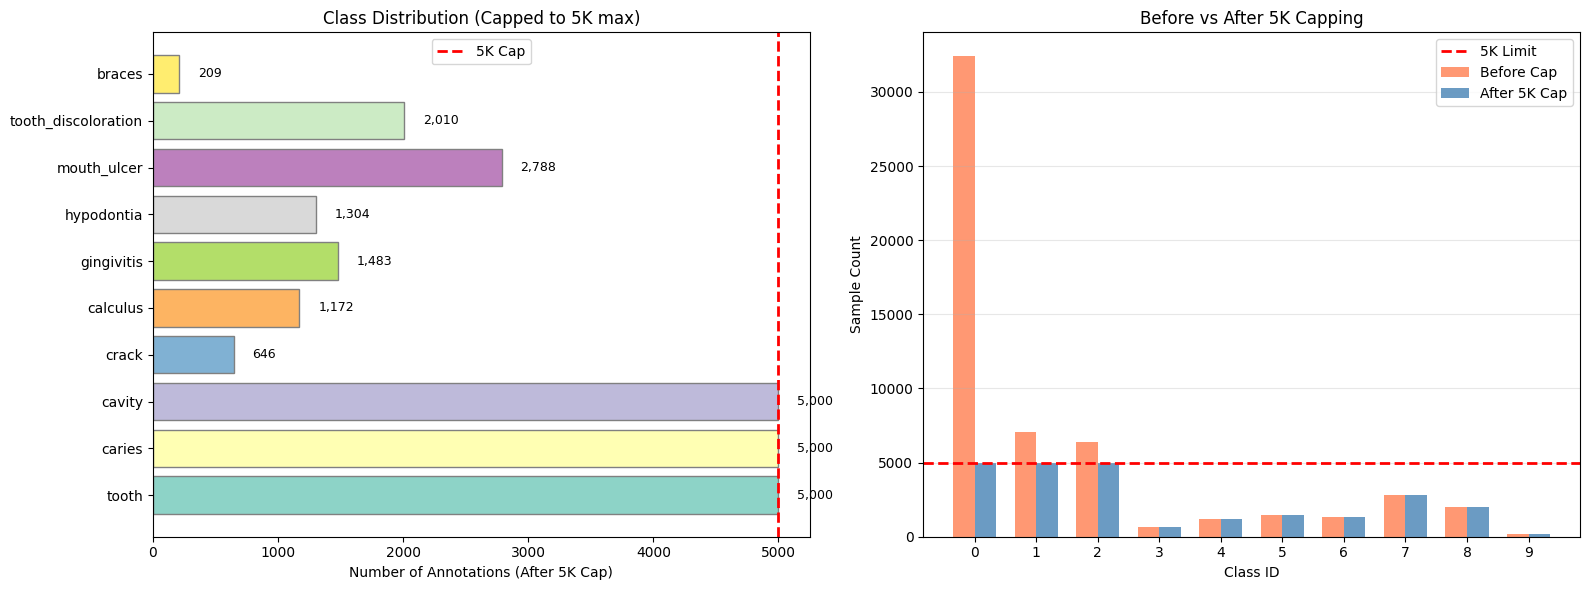

📊 Chart saved to class_balance_analysis.png

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Classes above 5K detected. Run: cap_dataset_to_5k()
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


In [1]:
import yaml
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from collections import defaultdict
import shutil
import random

MERGED_DIR = Path("./yolo_dataset_merged")
MAX_SAMPLES_PER_CLASS = 5000  # 🔥 CAP: Limit each class to 5k samples

# Load config
with open(MERGED_DIR / "data.yaml") as f:
    config = yaml.safe_load(f)

NUM_CLASSES = config["nc"]
CLASS_NAMES = config["names"]

# ── Count annotations per class per split ────────────────────────────────
split_class_counts = {}
for split in ['train', 'val', 'test']:
    counts = defaultdict(int)
    lbl_dir = MERGED_DIR / split / "labels"
    if lbl_dir.exists():
        for lbl in lbl_dir.glob("*.txt"):
            for line in lbl.read_text().strip().splitlines():
                parts = line.strip().split()
                if parts:
                    try:
                        counts[int(parts[0])] += 1
                    except ValueError:
                        pass
    split_class_counts[split] = counts

# Combined counts
total_counts = defaultdict(int)
for counts in split_class_counts.values():
    for cid, cnt in counts.items():
        total_counts[cid] += cnt

total_annots = sum(total_counts.values())
ideal_per_class = total_annots / NUM_CLASSES if NUM_CLASSES else 0

# ── Print table ──────────────────────────────────────────────────────────
print("=" * 100)
print("CLASS BALANCE ANALYSIS (WITH 5K CAP)")
print("=" * 100)
print(f"{'ID':<4} {'Class':<22} {'Train':>7} {'Val':>7} {'Test':>7} {'Total':>8} {'%':>7} {'After 5K Cap':>12} {'Status'}")
print("-" * 100)

counts_list = []
capped_counts = []
classes_to_cap = []

for cid in range(NUM_CLASSES):
    name = CLASS_NAMES[cid]
    tr = split_class_counts['train'].get(cid, 0)
    va = split_class_counts['val'].get(cid, 0)
    te = split_class_counts['test'].get(cid, 0)
    tot = total_counts.get(cid, 0)
    pct = (tot / total_annots * 100) if total_annots else 0
    counts_list.append(tot)
    
    # Calculate capped value
    capped = min(tot, MAX_SAMPLES_PER_CLASS)
    capped_counts.append(capped)
    
    if tot > MAX_SAMPLES_PER_CLASS:
        classes_to_cap.append((cid, name, tot, capped, tot - capped))

    # Status assessment
    if tot == 0:
        status = "❌ MISSING"
    elif tot > MAX_SAMPLES_PER_CLASS:
        status = f"⚠️  OVER (needs -{tot - MAX_SAMPLES_PER_CLASS})"
    elif tot < ideal_per_class * 0.2:
        status = "🔴 LOW"
    elif tot < ideal_per_class * 0.5:
        status = "🟠 UNDER"
    else:
        status = "✅ OK"

    print(f"{cid:<4} {name:<22} {tr:>7} {va:>7} {te:>7} {tot:>8} {pct:>6.1f}% {capped:>12,} {status}")

# ── Imbalance metrics ────────────────────────────────────────────────────
nonzero = [c for c in capped_counts if c > 0]
if len(nonzero) >= 2:
    ratio = max(nonzero) / min(nonzero)
    std   = np.std(nonzero)
    mean  = np.mean(nonzero)
    cv    = std / mean * 100  # coefficient of variation
else:
    ratio, cv = 0, 0

original_nonzero = [c for c in counts_list if c > 0]
if len(original_nonzero) >= 2:
    original_ratio = max(original_nonzero) / min(original_nonzero)
else:
    original_ratio = 0

capped_annots = sum(capped_counts)

print(f"\n{'─' * 100}")
print(f"  BEFORE CAPPING:")
print(f"    Total annotations:     {total_annots:,}")
print(f"    Imbalance ratio:       {original_ratio:.1f}x  (max/min)")
print(f"\n  AFTER CAPPING @ {MAX_SAMPLES_PER_CLASS:,} per class:")
print(f"    Total annotations:     {capped_annots:,} (reduction: {total_annots - capped_annots:,})")
print(f"    Imbalance ratio:       {ratio:.1f}x  (max/min)")
print(f"    Coefficient of var:    {cv:.1f}%")

if classes_to_cap:
    print(f"\n  🔥 CLASSES EXCEEDING 5K (to be capped):")
    for cid, name, tot, capped, excess in classes_to_cap:
        print(f"     • {name:<22} {tot:>6,} → {capped:>6,}  (remove {excess:>6,})")

if ratio > 3:
    print(f"\n  ⚠️  Still has moderate imbalance ({ratio:.1f}x after capping)")
else:
    print(f"\n  ✅ Much better balance ({ratio:.1f}x after capping)")

# ── Bar chart (AFTER CAPPING) ────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Absolute counts (with capping)
colors = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES))
bars = ax1.barh(CLASS_NAMES, capped_counts, color=colors, edgecolor='gray')
ax1.axvline(x=MAX_SAMPLES_PER_CLASS, color='red', linestyle='--', linewidth=2, label=f'5K Cap')
ax1.set_xlabel("Number of Annotations (After 5K Cap)")
ax1.set_title("Class Distribution (Capped to 5K max)")
ax1.legend()
for bar, cnt in zip(bars, capped_counts):
    ax1.text(bar.get_width() + 150, bar.get_y() + bar.get_height()/2, f'{cnt:,}',
             va='center', fontsize=9)

# Comparison: before vs after
x = np.arange(NUM_CLASSES)
width = 0.35
ax2.bar(x - width/2, counts_list, width, label='Before Cap', alpha=0.8, color='coral')
ax2.bar(x + width/2, capped_counts, width, label='After 5K Cap', alpha=0.8, color='steelblue')
ax2.axhline(y=MAX_SAMPLES_PER_CLASS, color='red', linestyle='--', linewidth=2, label='5K Limit')
ax2.set_xlabel("Class ID")
ax2.set_ylabel("Sample Count")
ax2.set_title("Before vs After 5K Capping")
ax2.set_xticks(x)
ax2.set_xticklabels(range(NUM_CLASSES))
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("class_balance_analysis.png", dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved to class_balance_analysis.png")

# ── Function to actually cap the dataset ────────────────────────────────
def cap_dataset_to_5k():
    """Cap each class to max 5000 samples and save to yolo_dataset_balanced"""
    print("\n" + "="*100)
    print("🔥 CAPPING DATASET TO 5K SAMPLES PER CLASS")
    print("="*100 + "\n")
    
    OUTPUT_DIR = Path("./yolo_dataset_balanced")
    OUTPUT_DIR.mkdir(exist_ok=True)
    
    # Copy data.yaml
    shutil.copy(MERGED_DIR / "data.yaml", OUTPUT_DIR / "data.yaml")
    print(f"✅ Copied data.yaml")
    
    # Process each split
    for split in ['train', 'val', 'test']:
        class_image_map = defaultdict(list)  # Map class_id -> [(img_file, lbl_file), ...]
        
        # Build mapping
        lbl_dir = MERGED_DIR / split / "labels"
        img_dir = MERGED_DIR / split / "images"
        
        if lbl_dir.exists() and img_dir.exists():
            for lbl_file in lbl_dir.glob("*.txt"):
                img_file = img_dir / (lbl_file.stem + ".jpg")
                if not img_file.exists():
                    img_file = img_dir / (lbl_file.stem + ".png")
                
                # Get classes in this image
                classes_in_image = set()
                for line in lbl_file.read_text().strip().splitlines():
                    parts = line.strip().split()
                    if parts:
                        try:
                            class_id = int(parts[0])
                            classes_in_image.add(class_id)
                        except ValueError:
                            pass
                
                # Add to each class it belongs to
                for class_id in classes_in_image:
                    class_image_map[class_id].append((img_file, lbl_file))
        
        # Create output directories
        out_img_dir = OUTPUT_DIR / split / "images"
        out_lbl_dir = OUTPUT_DIR / split / "labels"
        out_img_dir.mkdir(parents=True, exist_ok=True)
        out_lbl_dir.mkdir(parents=True, exist_ok=True)
        
        # Sample and copy
        copied_pairs = set()
        for class_id, image_pairs in class_image_map.items():
            # Randomly sample up to 5k
            sampled = random.sample(image_pairs, min(len(image_pairs), MAX_SAMPLES_PER_CLASS))
            for img_file, lbl_file in sampled:
                copied_pairs.add(lbl_file)
                if img_file.exists():
                    shutil.copy2(img_file, out_img_dir / img_file.name)
                if lbl_file.exists():
                    shutil.copy2(lbl_file, out_lbl_dir / lbl_file.name)
        
        print(f"✅ {split.upper():5} split: copied {len(copied_pairs):,} files")
    
    print("\n✅ Dataset capped and saved to: yolo_dataset_balanced/\n")

# Only run if needed (classes exceeded 5k)
if classes_to_cap:
    print("\n" + "!"*100)
    print("Classes above 5K detected. Run: cap_dataset_to_5k()")
    print("!"*100)

## Step 6b — Class Balancing (conservative, ≤2× augmentation)
Apply hybrid over/under-sampling **to training set only**. Val/test are **subsampled** to maintain proper split ratios:
- **Undersample** `tooth`, `caries`, `cavity` to ~2,500
- **Augment minority classes ≤2×** to avoid overfitting on augmented copies
- **Val/test subsampled** to ~15%/5% of training size (fixes inverted ratio)
- Target: 1,100–2,500 per class, ≤2.3× imbalance ratio
- Optimized for **50-epoch fine-tuning** from existing best.pt

In [7]:
import shutil, random, yaml, os
import numpy as np
from pathlib import Path
from collections import defaultdict
from PIL import Image, ImageEnhance, ImageFilter

random.seed(42)
np.random.seed(42)

# ── Config ───────────────────────────────────────────────────────────────
SRC_DIR = Path("./yolo_dataset_merged")
BAL_DIR = Path("./yolo_dataset_balanced")
VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Load class config from merged dataset
with open(SRC_DIR / "data.yaml") as f:
    config = yaml.safe_load(f)
CLASS_NAMES = config["names"]

# Conservative targets — limit augmentation to ≤2× to prevent overfitting
# during 50-epoch fine-tuning. Accept mild imbalance (≤2.3×) which YOLO
# handles well with its built-in mosaic/mixup augmentations.
TARGET_ANNOTATIONS = {
    0: 2500,   # tooth          — undersample from 28,081
    1: 2500,   # caries         — undersample from 5,758
    2: 2500,   # cavity         — undersample from 5,683
    3: 1100,   # crack          — augment ~2× from 586
    4: 1500,   # calculus       — augment ~1.7× from 885
    5: 1500,   # gingivitis     — augment ~1.4× from 1,068
    6: 1500,   # hypodontia     — augment ~1.5× from 1,009
    7: 2200,   # mouth_ulcer    — keep ~as-is from 2,226
    8: 1600,   # tooth_discolor — keep ~as-is from 1,606
}

MAX_AUG_RATIO = 2.0  # Never augment beyond 2× original count

# Use 9 classes (exclude class 9 'braces' — too few samples)
NUM_CLASSES = len(TARGET_ANNOTATIONS)

# Val/test subsampling (proper 80/15/5 ratio)
VAL_MAX  = 1200   # down from 1,766
TEST_MAX = 400    # down from 840

TOTAL_TARGET = sum(TARGET_ANNOTATIONS.values())
est_images = int(TOTAL_TARGET / 1.5)
steps = est_images // 16

print("📊 Dataset Sizing (conservative for 50-epoch fine-tuning):")
print(f"   Classes:            {NUM_CLASSES}")
print(f"   Total target annot: {TOTAL_TARGET:,}")
print(f"   Est training imgs:  ~{est_images:,}")
print(f"   Steps/epoch (bs=16):~{steps}")
print(f"   Max aug ratio:      {MAX_AUG_RATIO}×")
print(f"   Val max:            {VAL_MAX}")
print(f"   Test max:           {TEST_MAX}")
print(f"\n   Per-class targets:")
for cid in range(NUM_CLASSES):
    print(f"     {cid}: {CLASS_NAMES[cid]:<22} → {TARGET_ANNOTATIONS[cid]:>5,}")

# ── Clean old output ─────────────────────────────────────────────────────
print("\n🧹 Cleaning output directories...")
if BAL_DIR.exists():
    shutil.rmtree(BAL_DIR, ignore_errors=True)

for split in ['train', 'val', 'test']:
    (BAL_DIR / split / "images").mkdir(parents=True, exist_ok=True)
    (BAL_DIR / split / "labels").mkdir(parents=True, exist_ok=True)
print("   Done.")

# ── Augmentation functions ───────────────────────────────────────────────
def augment_image(img_path, output_path, intensity="normal"):
    """Apply random augmentations and save. Returns True if horizontally flipped."""
    try:
        img = Image.open(img_path).convert("RGB")
    except Exception:
        shutil.copy(img_path, output_path)
        return False

    transforms = []
    if random.random() > 0.5:
        transforms.append("hflip")
    if random.random() > 0.4:
        transforms.append("brightness")
    if random.random() > 0.4:
        transforms.append("contrast")
    if random.random() > 0.5:
        transforms.append("rotate")

    if intensity == "heavy":
        transforms.extend(["color", "sharpness"])
        if random.random() > 0.3:
            transforms.append("blur")

    for t in transforms:
        if t == "hflip":
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
        elif t == "brightness":
            img = ImageEnhance.Brightness(img).enhance(random.uniform(0.7, 1.4))
        elif t == "contrast":
            img = ImageEnhance.Contrast(img).enhance(random.uniform(0.7, 1.4))
        elif t == "rotate":
            img = img.rotate(random.uniform(-15, 15), fillcolor=(0, 0, 0), expand=False)
        elif t == "color":
            img = ImageEnhance.Color(img).enhance(random.uniform(0.7, 1.3))
        elif t == "sharpness":
            img = ImageEnhance.Sharpness(img).enhance(random.uniform(0.5, 2.0))
        elif t == "blur":
            img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 1.5)))

    img.save(output_path, quality=95)
    return "hflip" in transforms


def mirror_labels_horizontal(label_lines):
    """Mirror YOLO bounding box labels for a horizontal flip."""
    mirrored = []
    for line in label_lines:
        parts = line.strip().split()
        if len(parts) != 5:
            mirrored.append(line)
            continue
        cid = parts[0]
        xc, yc, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        mirrored.append(f"{cid} {1.0 - xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")
    return mirrored


def fast_copy(src, dst):
    """Copy file, trying hard link first for speed on OneDrive."""
    try:
        os.link(src, dst)
    except (OSError, NotImplementedError):
        shutil.copy2(src, dst)


# ── STEP 1: Subsample & copy val/test ────────────────────────────────────
print(f"\n{'=' * 65}")
print("STEP 1: SUBSAMPLE VAL & TEST SETS")
print("=" * 65)

for split, max_n in [('val', VAL_MAX), ('test', TEST_MAX)]:
    src_imgs = SRC_DIR / split / "images"
    src_lbls = SRC_DIR / split / "labels"
    if not src_imgs.exists():
        print(f"  {split}: source not found — skipping")
        continue

    # Get all paired files
    candidates = []
    for img_path in src_imgs.iterdir():
        if img_path.suffix.lower() not in VALID_EXTS:
            continue
        lbl_path = src_lbls / (img_path.stem + ".txt")
        if lbl_path.exists():
            candidates.append((img_path, lbl_path))

    # Subsample if needed
    if len(candidates) > max_n:
        random.shuffle(candidates)
        candidates = candidates[:max_n]

    for img_path, lbl_path in candidates:
        fast_copy(img_path, BAL_DIR / split / "images" / img_path.name)
        fast_copy(lbl_path, BAL_DIR / split / "labels" / lbl_path.name)

    print(f"  📋 {split}: {len(candidates)} samples (from {len(list(src_imgs.iterdir()))})")


# ── STEP 2: Index training set ───────────────────────────────────────────
print(f"\n{'=' * 65}")
print("STEP 2: INDEXING TRAINING SET")
print("=" * 65)

train_img_dir = SRC_DIR / "train" / "images"
train_lbl_dir = SRC_DIR / "train" / "labels"

image_annots  = {}   # stem -> list of label lines
class_images  = defaultdict(list)  # class_id -> list of stems

for lbl_path in sorted(train_lbl_dir.glob("*.txt")):
    stem = lbl_path.stem
    lines = lbl_path.read_text().strip().splitlines()
    if not lines:
        continue
    image_annots[stem] = lines
    seen_classes = set()
    for line in lines:
        parts = line.strip().split()
        if parts:
            try:
                cid = int(parts[0])
                if cid < NUM_CLASSES:
                    seen_classes.add(cid)
            except ValueError:
                pass
    for cid in seen_classes:
        class_images[cid].append(stem)

# Count current annotations per class
current_counts = defaultdict(int)
for stem, lines in image_annots.items():
    for line in lines:
        parts = line.strip().split()
        if parts:
            try:
                cid = int(parts[0])
                if cid < NUM_CLASSES:
                    current_counts[cid] += 1
            except ValueError:
                pass

print(f"  Indexed {len(image_annots):,} training images")
print("\n  Source training annotations:")
for cid in range(NUM_CLASSES):
    target = TARGET_ANNOTATIONS[cid]
    avail  = current_counts[cid]
    action = "↓ undersample" if avail > target else ("↑ augment" if avail < target else "= keep")
    print(f"    {cid}: {CLASS_NAMES[cid]:<22} {avail:>6,} → {target:>5,}  {action}")


# ── STEP 3: Smart select base images (prioritize minority classes) ───────
print(f"\n{'=' * 65}")
print("STEP 3: SELECT BASE TRAINING IMAGES")
print("=" * 65)

selected_stems = set()
class_annot_selected = defaultdict(int)

# Process classes from smallest to largest (minority first)
class_order = sorted(range(NUM_CLASSES), key=lambda c: current_counts.get(c, 0))

for cid in class_order:
    target = TARGET_ANNOTATIONS[cid]
    candidates = class_images.get(cid, [])
    if not candidates:
        print(f"  {cid}: {CLASS_NAMES[cid]:<22} — no source images")
        continue

    random.shuffle(candidates)

    for stem in candidates:
        # Count annotations of THIS class in this image
        annots_of_class = sum(
            1 for line in image_annots[stem]
            if line.strip().split()[0] == str(cid)
        )

        if class_annot_selected[cid] + annots_of_class <= target:
            if stem not in selected_stems:
                selected_stems.add(stem)
                # Count ALL classes in this image for tracking
                for line in image_annots[stem]:
                    parts = line.strip().split()
                    if parts:
                        try:
                            c = int(parts[0])
                            if c < NUM_CLASSES:
                                class_annot_selected[c] += 1
                        except ValueError:
                            pass
            else:
                # Image already selected, just track the count
                class_annot_selected[cid] += annots_of_class

print(f"  Selected {len(selected_stems):,} base images")
print("  Base annotations per class:")
for cid in range(NUM_CLASSES):
    target = TARGET_ANNOTATIONS[cid]
    actual = class_annot_selected[cid]
    status = "✅" if actual >= target * 0.9 else "🔶 needs augmentation"
    print(f"    {cid}: {CLASS_NAMES[cid]:<22} {actual:>6,} / {target:>5,}  {status}")


# ── STEP 4: Copy base images ────────────────────────────────────────────
print(f"\n{'=' * 65}")
print("STEP 4: COPY BASE TRAINING IMAGES")
print("=" * 65)

idx = 0
stem_to_idx = {}

for stem in sorted(selected_stems):
    # Find image file
    img_path = None
    for ext in ['.jpg', '.jpeg', '.png', '.bmp', '.webp']:
        candidate = train_img_dir / f"{stem}{ext}"
        if candidate.exists():
            img_path = candidate
            break
    if img_path is None:
        # Try glob fallback
        matches = list(train_img_dir.glob(f"{stem}.*"))
        for m in matches:
            if m.suffix.lower() in VALID_EXTS:
                img_path = m
                break
    if img_path is None:
        continue

    new_name = f"bal_{idx:06d}"
    fast_copy(img_path, BAL_DIR / "train" / "images" / f"{new_name}{img_path.suffix}")
    (BAL_DIR / "train" / "labels" / f"{new_name}.txt").write_text(
        "\n".join(image_annots[stem])
    )
    stem_to_idx[stem] = (idx, img_path)
    idx += 1

    if (idx) % 1000 == 0:
        print(f"    Progress: {idx:,} images copied...")

print(f"  ✅ Copied {idx:,} base training images")


# ── STEP 5: Augment minority classes (≤2× original, per-class targets) ──
print(f"\n{'=' * 65}")
print("STEP 5: AUGMENT MINORITY CLASSES")
print("=" * 65)

# Recount annotations from copied files
bal_counts = defaultdict(int)
for lbl in (BAL_DIR / "train" / "labels").glob("*.txt"):
    for line in lbl.read_text().strip().splitlines():
        parts = line.strip().split()
        if parts:
            try:
                c = int(parts[0])
                if c < NUM_CLASSES:
                    bal_counts[c] += 1
            except ValueError:
                pass

aug_idx = idx  # Continue numbering from base images
total_augmented = 0

for cid in range(NUM_CLASSES):
    target = TARGET_ANNOTATIONS[cid]
    current = bal_counts[cid]

    # Enforce MAX_AUG_RATIO — never augment beyond 2× original count
    max_allowed = int(current * MAX_AUG_RATIO)
    effective_target = min(target, max_allowed)
    deficit = effective_target - current

    if deficit <= 0:
        continue

    # Get stems that contain this class (from selected set)
    aug_candidates = [
        stem for stem in selected_stems
        if any(line.strip().split()[0] == str(cid) for line in image_annots[stem])
    ]

    if not aug_candidates:
        print(f"  {cid}: {CLASS_NAMES[cid]:<22} — no candidates for augmentation")
        continue

    intensity = "normal"  # Conservative — all targets within 2× ratio
    annots_added = 0
    aug_round = 0

    print(f"  {cid}: {CLASS_NAMES[cid]:<22} {current:>5,} → {effective_target:>5,} (deficit: {deficit:>5,}, aug ratio: {effective_target/current:.1f}×)")

    while annots_added < deficit:
        for stem in aug_candidates:
            if annots_added >= deficit:
                break

            orig_idx, orig_img_path = stem_to_idx.get(stem, (None, None))
            if orig_img_path is None:
                continue

            # Count how many annotations of this class
            annots_of_class = sum(
                1 for line in image_annots[stem]
                if line.strip().split()[0] == str(cid)
            )

            # Create augmented copy
            new_name = f"aug_{aug_idx:06d}"
            out_img = BAL_DIR / "train" / "images" / f"{new_name}{orig_img_path.suffix}"
            flipped = augment_image(orig_img_path, out_img, intensity=intensity)

            # Write label (mirror if flipped)
            lines = image_annots[stem]
            if flipped:
                lines = mirror_labels_horizontal(lines)
            (BAL_DIR / "train" / "labels" / f"{new_name}.txt").write_text("\n".join(lines))

            aug_idx += 1
            annots_added += annots_of_class
            total_augmented += 1

        aug_round += 1
        if aug_round > 20:  # Safety limit
            print(f"    ⚠️  Hit augmentation round limit for {CLASS_NAMES[cid]}")
            break

print(f"\n  ✅ Created {total_augmented:,} augmented images (total training: {aug_idx:,})")


# ── Write data.yaml ──────────────────────────────────────────────────────
bal_abs = str(BAL_DIR.resolve())
yaml_content = f"""train: {bal_abs}/train/images
val: {bal_abs}/val/images
test: {bal_abs}/test/images

nc: {NUM_CLASSES}
names: {CLASS_NAMES[:NUM_CLASSES]}
"""
(BAL_DIR / "data.yaml").write_text(yaml_content)


# ── Final distribution ───────────────────────────────────────────────────
print(f"\n{'=' * 65}")
print("FINAL BALANCED DISTRIBUTION (train)")
print("=" * 65)

final_counts = defaultdict(int)
for lbl in (BAL_DIR / "train" / "labels").glob("*.txt"):
    for line in lbl.read_text().strip().splitlines():
        parts = line.strip().split()
        if parts:
            try:
                c = int(parts[0])
                if c < NUM_CLASSES:
                    final_counts[c] += 1
            except ValueError:
                pass

total_final = sum(final_counts.values())
nonzero = [c for c in final_counts.values() if c > 0]
final_ratio = max(nonzero) / min(nonzero) if len(nonzero) >= 2 and min(nonzero) > 0 else 0

for cid in range(NUM_CLASSES):
    before = current_counts.get(cid, 0)
    after  = final_counts.get(cid, 0)
    target = TARGET_ANNOTATIONS[cid]
    pct    = after / total_final * 100 if total_final else 0
    bar    = "█" * int(pct * 2)
    change = f"+{after - before}" if after >= before else f"{after - before}"
    hit    = "✅" if abs(after - target) < target * 0.15 else "⚠️"
    print(f"  {cid}: {CLASS_NAMES[cid]:<22} {before:>6,} → {after:>6,} ({change:>7}) {pct:>5.1f}% {hit} {bar}")

print(f"\n  Total annotations: {total_final:,}")
print(f"  Imbalance ratio:   {final_ratio:.1f}x")


print(f"\n✅ Balanced dataset saved to: {BAL_DIR}")
for split in ['train', 'val', 'test']:
    n = len(list((BAL_DIR / split / "images").glob("*")))
    print(f"   {split:>5}: {n:,} images")

📊 Dataset Sizing (conservative for 50-epoch fine-tuning):
   Classes:            9
   Total target annot: 16,900
   Est training imgs:  ~11,266
   Steps/epoch (bs=16):~704
   Max aug ratio:      2.0×
   Val max:            1200
   Test max:           400

   Per-class targets:
     0: tooth                  → 2,500
     1: caries                 → 2,500
     2: cavity                 → 2,500
     3: crack                  → 1,100
     4: calculus               → 1,500
     5: gingivitis             → 1,500
     6: hypodontia             → 1,500
     7: mouth_ulcer            → 2,200
     8: tooth_discoloration    → 1,600

🧹 Cleaning output directories...
   Done.

STEP 1: SUBSAMPLE VAL & TEST SETS
  📋 val: 1200 samples (from 1766)
  📋 test: 400 samples (from 840)

STEP 2: INDEXING TRAINING SET
  Indexed 11,254 training images

  Source training annotations:
    0: tooth                  28,081 → 2,500  ↓ undersample
    1: caries                  5,758 → 2,500  ↓ undersample
    2: cav

---
## Step 7 — Fine-tune YOLOv8 Model (50 epochs)
Fine-tune on the **balanced** dataset (`yolo_dataset_balanced/data.yaml`) with conservative targets and ≤2× augmentation.

In [8]:
# Cell: Part 3 - Train the Model

from ultralytics import YOLO
from pathlib import Path
import os
import torch

# ============================================
# CONFIGURATION
# ============================================

# Path to your data.yaml file (use balanced dataset)
DATA_YAML = str(Path("yolo_dataset_balanced/data.yaml").resolve())

# Auto-detect device
DEVICE = 0 if torch.cuda.is_available() else "cpu"
print(f"🖥️  Using device: {'GPU (CUDA)' if DEVICE == 0 else 'CPU'}")
if DEVICE == "cpu":
    print("   ⚠️  Training on CPU will be very slow. GPU recommended.")

# ============================================
# GPU MEMORY OPTIMIZATION
# ============================================
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    reserved_memory = torch.cuda.memory_reserved(0) / 1e9
    allocated_memory = torch.cuda.memory_allocated(0) / 1e9
    free_memory = (total_memory - allocated_memory)
    
    print(f"GPU Memory Status:")
    print(f"  Total:     {total_memory:.2f}GB")
    print(f"  Allocated: {allocated_memory:.2f}GB")
    print(f"  Reserved:  {reserved_memory:.2f}GB")
    print(f"  Free:      {free_memory:.2f}GB")

# ============================================
# TRANSFER LEARNING CONFIGURATION
# ============================================
USE_PREVIOUS_WEIGHTS = True  # 🔄 Fine-tune from previous best run
PREFERRED_RUN = "YOLOv8_Training8"  # Best completed run (200 epochs, mAP50=67.93%)

# Auto-detect model weights
RUNS_DIR = Path("runs/detect/Dental_Detection")
PREVIOUS_MODEL_PATH = None

if USE_PREVIOUS_WEIGHTS and RUNS_DIR.exists():
    def find_best_pt(run_dir):
        """Search for best.pt in a run dir (handles nested structures)."""
        direct = run_dir / "weights" / "best.pt"
        if direct.exists():
            return direct
        for sub in run_dir.iterdir():
            if sub.is_dir():
                nested = sub / "weights" / "best.pt"
                if nested.exists():
                    return nested
        return None

    # Try preferred run first
    preferred_dir = RUNS_DIR / PREFERRED_RUN
    if preferred_dir.exists():
        best = find_best_pt(preferred_dir)
        if best:
            PREVIOUS_MODEL_PATH = str(best)
            print(f"🔍 Using preferred run: {best}")

    # Fallback: search all runs from latest to oldest
    if PREVIOUS_MODEL_PATH is None:
        training_dirs = sorted(
            [d for d in RUNS_DIR.iterdir() if d.is_dir() and d.name.startswith("YOLOv8_Training")],
            key=lambda d: int(''.join(filter(str.isdigit, d.name)) or "0"),
            reverse=True
        )
        for d in training_dirs:
            best = find_best_pt(d)
            if best:
                PREVIOUS_MODEL_PATH = str(best)
                print(f"🔍 Found model (fallback): {best}")
                break

    if PREVIOUS_MODEL_PATH is None:
        print("⚠️  No best.pt found in any training run — will train from scratch")
        USE_PREVIOUS_WEIGHTS = False

# Training hyperparameters - OPTIMIZED FOR FINE-TUNING (50 epochs)
CONFIG = {
    "model": "yolov8s.pt",
    "epochs": 50,
    "batch_size": 8,
    "img_size": 640,
    "patience": 15,
    "lr0": 0.00005,
    "lrf": 0.05,
    "warmup_epochs": 2,
    "freeze": 10,
    "device": DEVICE,
}

print(f"\n⚙️  Training Config:")
print(f"  Mode:        {'Fine-tuning' if USE_PREVIOUS_WEIGHTS else 'Training from scratch'}")
print(f"  Batch Size:  {CONFIG['batch_size']}")
print(f"  Image Size:  {CONFIG['img_size']}x{CONFIG['img_size']}")
print(f"  Epochs:      {CONFIG['epochs']}")
print(f"  Patience:    {CONFIG['patience']} (early stopping)")
print(f"  Learning Rate: {CONFIG['lr0']} → {CONFIG['lr0'] * CONFIG['lrf']:.6f} (cosine)")
print(f"  Freeze:      {CONFIG['freeze']} backbone layers")

# ============================================
# LOAD PRE-TRAINED MODEL
# ============================================
if USE_PREVIOUS_WEIGHTS and PREVIOUS_MODEL_PATH:
    print(f"\n🔄 FINE-TUNING MODE")
    try:
        print(f"📦 Loading model from: {PREVIOUS_MODEL_PATH}")
        model = YOLO(PREVIOUS_MODEL_PATH)
        print(f"✅ Model loaded successfully!")
    except Exception as e:
        print(f"⚠️  Error loading model: {e}")
        print(f"   Falling back to base model: yolov8s.pt")
        model = YOLO("yolov8s.pt")
        USE_PREVIOUS_WEIGHTS = False
else:
    print(f"\n📦 Training from scratch with base model: {CONFIG['model']}")
    model = YOLO(CONFIG["model"])

print(f"\nModel info:")
print(f"  Parameters: {sum(p.numel() for p in model.model.parameters()):,}")
if USE_PREVIOUS_WEIGHTS:
    print(f"  Source:      {PREVIOUS_MODEL_PATH}")
    print(f"  Freeze:      first {CONFIG['freeze']} layers (backbone)")

# ============================================
# TRAIN THE MODEL
# ============================================
print(f"\n{'='*60}")
print(f"STARTING {'FINE-TUNING' if USE_PREVIOUS_WEIGHTS else 'TRAINING'}")
print(f"{'='*60}\n")

try:
    results = model.train(
        data=DATA_YAML,
        epochs=CONFIG["epochs"],
        batch=CONFIG["batch_size"],
        imgsz=CONFIG["img_size"],
        patience=CONFIG["patience"],

        project="runs/detect/Dental_Detection",
        name="YOLOv8_Training",
        exist_ok=False,
        save_period=10,

        # Memory optimization
        amp=True,
        device=CONFIG["device"],
        workers=0,

        # Reduced online augmentation — data is ALREADY pre-augmented in Step 6b
        hsv_h=0.01,
        hsv_s=0.4,
        hsv_v=0.3,
        degrees=10.0,
        translate=0.1,
        scale=0.3,
        flipud=0.0,
        fliplr=0.5,
        mosaic=0.8,
        mixup=0.05,

        # Fine-tuning optimizer settings
        optimizer='SGD',
        lr0=CONFIG["lr0"],
        lrf=CONFIG["lrf"],
        warmup_epochs=CONFIG["warmup_epochs"],
        weight_decay=0.0005,
        cos_lr=True,
        freeze=CONFIG["freeze"],
        val=True,
    )

    print(f"\n{'='*60}")
    print(f"{'FINE-TUNING' if USE_PREVIOUS_WEIGHTS else 'TRAINING'} COMPLETED!")
    print(f"{'='*60}\n")

    # ============================================
    # BEST MODEL PATH
    # ============================================
    TRAIN_OUTPUT = Path(results.save_dir)
    BEST_MODEL_PATH = str(TRAIN_OUTPUT / "weights" / "best.pt")
    MODEL_PATH = BEST_MODEL_PATH

    if Path(BEST_MODEL_PATH).exists():
        print(f"✅ Best model saved at: {BEST_MODEL_PATH}")
    else:
        LAST_MODEL_PATH = str(TRAIN_OUTPUT / "weights" / "last.pt")
        MODEL_PATH = LAST_MODEL_PATH
        print(f"✅ Model saved at: {LAST_MODEL_PATH}")

    # ============================================
    # PRINT FINAL METRICS
    # ============================================
    print("\nFinal Training Results:")
    
    metrics_dict = results.results_dict
    
    mAP50 = metrics_dict.get('metrics/mAP50(B)', 0) * 100
    mAP50_95 = metrics_dict.get('metrics/mAP50-95(B)', 0) * 100
    precision = metrics_dict.get('metrics/precision(B)', 0) * 100
    recall = metrics_dict.get('metrics/recall(B)', 0) * 100
    
    print(f"  📊 Best mAP50:      {mAP50:.2f}%")
    print(f"  📊 Best mAP50-95:   {mAP50_95:.2f}%")
    print(f"  🎯 Precision:       {precision:.2f}%")
    print(f"  🔍 Recall:          {recall:.2f}%")
    
    if precision > 0 and recall > 0:
        f1 = 2 * (precision * recall) / (precision + recall)
        print(f"  ✅ F1-Score:        {f1:.2f}%")
    
    if USE_PREVIOUS_WEIGHTS:
        print(f"\n🎯 Fine-tuning Summary:")
        print(f"   ✓ Loaded weights from: {PREVIOUS_MODEL_PATH}")
        print(f"   ✓ Froze {CONFIG['freeze']} backbone layers")
        print(f"   ✓ Cosine LR: {CONFIG['lr0']} → {CONFIG['lr0'] * CONFIG['lrf']:.6f}")
        print(f"   ✓ Reduced online augmentation (pre-augmented data)")

finally:
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

🖥️  Using device: GPU (CUDA)
GPU Memory Status:
  Total:     6.44GB
  Allocated: 0.00GB
  Reserved:  0.00GB
  Free:      6.44GB
🔍 Using preferred run: runs\detect\Dental_Detection\YOLOv8_Training8\YOLOv8_Training8\weights\best.pt

⚙️  Training Config:
  Mode:        Fine-tuning
  Batch Size:  8
  Image Size:  640x640
  Epochs:      50
  Patience:    15 (early stopping)
  Learning Rate: 5e-05 → 0.000003 (cosine)
  Freeze:      10 backbone layers

🔄 FINE-TUNING MODE
📦 Loading model from: runs\detect\Dental_Detection\YOLOv8_Training8\YOLOv8_Training8\weights\best.pt
✅ Model loaded successfully!

Model info:
  Parameters: 11,139,083
  Source:      runs\detect\Dental_Detection\YOLOv8_Training8\YOLOv8_Training8\weights\best.pt
  Freeze:      first 10 layers (backbone)

STARTING FINE-TUNING

New https://pypi.org/project/ultralytics/8.4.17 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.12  Python-3.14.0 torch-2.10.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 614

## Verify Dataset & Training Steps
Confirm balanced dataset is ready and calculate training steps per epoch.

In [ ]:

from pathlib import Path
import math

BAL_DIR = Path("./yolo_dataset_balanced")

# Count training images
train_images = list((BAL_DIR / "train" / "images").glob("*"))
n_train_images = len(train_images)

if n_train_images == 0:
    print("⚠️  WARNING: No training images found!")
    print("   Make sure the augmentation cell above was executed successfully.")
else:
    print("=" * 70)
    print("✅ DATASET READY FOR TRAINING")
    print("=" * 70)
    print(f"\nTraining images: {n_train_images:,}")
    
    # Calculate steps for batch size 16 (default)
    batch_size = 16
    steps_per_epoch = math.ceil(n_train_images / batch_size)
    max_allowed_steps = 2500
    
    ratio = steps_per_epoch / max_allowed_steps * 100
    status = "✅ OK" if steps_per_epoch <= max_allowed_steps else "⚠️  EXCEEDS"
    
    print(f"\nWith batch size {batch_size}:")
    print(f"  Steps per epoch: {steps_per_epoch:>5} ({ratio:>6.1f}% of {max_allowed_steps:,} max) {status}")
    
    print(f"\nDataset splits:")
    for split in ['train', 'val', 'test']:
        split_dir = BAL_DIR / split
        n_img = len(list((split_dir / "images").glob("*")))
        if n_img > 0:
            print(f"  {split:>5}: {n_img:>5} images")
    
    print(f"\n✅ Ready to train! Running cell below will start training...")


✅ DATASET READY FOR TRAINING

Training images: 1,217

With batch size 16:
  Steps per epoch:    77 (   3.1% of 2,500 max) ✅ OK

Dataset splits:
  train:  1217 images
    val:  2679 images
   test:  1396 images

✅ Ready to train! Running cell below will start training...


In [ ]:
# Cell: Part 4 - DentalDetector Class

from ultralytics import YOLO
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import numpy as np

class DentalDetector:
    """
    Dental Detection System
    
    Detects:
    - Teeth (generic tooth class)
    - Damage: caries, cavity, crack
    - Position: upper/lower, left/right (heuristic from bbox)
    """
    
    def __init__(self, model_path):
        """
        Initialize the detector
        
        Args:
            model_path: Path to trained YOLOv8 model (.pt file)
        """
        print(f"Loading model from: {model_path}")
        self.model = YOLO(model_path)
        
        # Read class names from the model itself
        self.class_names = self.model.names  # dict: {0: 'tooth', 1: 'caries', ...}
        
        # Categorize classes based on what the model actually knows
        self.tooth_classes = []
        self.damage_classes = []
        
        known_damage = {'caries', 'cavity', 'crack', 'decay'}
        known_teeth = {'tooth', 'incisor', 'canine', 'premolar', 'molar'}
        
        for class_id, class_name in self.class_names.items():
            lower_name = class_name.lower()
            if lower_name in known_teeth:
                self.tooth_classes.append(class_name)
            elif lower_name in known_damage:
                self.damage_classes.append(class_name)
            else:
                print(f"  ⚠️  Unknown class '{class_name}' (id={class_id}) — treating as damage")
                self.damage_classes.append(class_name)
        
        print("✅ Model loaded successfully!")
        print(f"   Model classes: {list(self.class_names.values())}")
        print(f"   Tooth classes: {self.tooth_classes}")
        print(f"   Damage classes: {self.damage_classes}")
    
    def determine_position(self, bbox, img_height):
        """
        Determine if detection is in upper or lower jaw.
        
        Note: This is a simple heuristic based on image midpoint.
        It works best with standardized dental X-ray framing.
        For production use, consider a separate jaw segmentation model.
        """
        y_center = (bbox[1] + bbox[3]) / 2
        return 'upper' if y_center < img_height / 2 else 'lower'
    
    def determine_side(self, bbox, img_width):
        """Determine if detection is on left or right side."""
        x_center = (bbox[0] + bbox[2]) / 2
        return 'left' if x_center < img_width / 2 else 'right'
    
    def detect(self, image_path, conf_threshold=0.5, iou_threshold=0.45):
        """
        Perform detection on an image.
        
        Args:
            image_path: Path to the input image
            conf_threshold: Confidence threshold (0-1)
            iou_threshold: IoU threshold for NMS
            
        Returns:
            dict with 'teeth' and 'damages' detections
        """
        results = self.model(
            image_path,
            conf=conf_threshold,
            iou=iou_threshold,
            verbose=False
        )
        
        img = Image.open(image_path)
        img_width, img_height = img.size
        
        teeth = []
        damages = []
        
        for result in results:
            boxes = result.boxes
            
            for box in boxes:
                class_id = int(box.cls.cpu().numpy())
                class_name = result.names[class_id]
                confidence = float(box.conf.cpu().numpy())
                bbox = box.xyxy[0].cpu().numpy().tolist()
                
                position = self.determine_position(bbox, img_height)
                side = self.determine_side(bbox, img_width)
                
                detection = {
                    'class': class_name,
                    'class_id': class_id,
                    'confidence': round(confidence, 4),
                    'bbox': [round(c, 2) for c in bbox],
                    'position': position,
                    'side': side,
                    'full_label': f"{position} {side} {class_name}"
                }
                
                if class_name in self.tooth_classes:
                    teeth.append(detection)
                else:
                    damages.append(detection)
        
        return {
            'teeth': teeth,
            'damages': damages,
            'image_path': str(image_path),
            'image_size': (img_width, img_height)
        }
    
    def visualize(self, image_path, detections, save_path=None):
        """Visualize detections on the image."""
        img = Image.open(image_path).convert("RGB")
        draw = ImageDraw.Draw(img)
        
        try:
            font = ImageFont.truetype("arial.ttf", 16)
        except:
            font = ImageFont.load_default()
        
        # Color map for different classes
        colors = {
            'tooth': "#00FF00",
            'caries': "#FF0000",
            'cavity': "#FF6600",
            'crack': "#FF00FF",
        }
        
        # Draw teeth (green boxes)
        for tooth in detections['teeth']:
            bbox = tooth['bbox']
            color = colors.get(tooth['class'], "#00FF00")
            
            draw.rectangle(bbox, outline=color, width=3)
            
            label = f"{tooth['full_label']} {tooth['confidence']:.0%}"
            text_bbox = draw.textbbox((bbox[0], bbox[1] - 25), label, font=font)
            draw.rectangle(text_bbox, fill=color)
            draw.text((bbox[0], bbox[1] - 25), label, fill="#000000", font=font)
        
        # Draw damages (red/orange boxes)
        for damage in detections['damages']:
            bbox = damage['bbox']
            color = colors.get(damage['class'], "#FF0000")
            
            draw.rectangle(bbox, outline=color, width=3)
            
            label = f"{damage['class'].upper()} {damage['confidence']:.0%}"
            text_bbox = draw.textbbox((bbox[0], bbox[1] - 25), label, font=font)
            draw.rectangle(text_bbox, fill=color)
            draw.text((bbox[0], bbox[1] - 25), label, fill="#FFFFFF", font=font)
        
        plt.figure(figsize=(15, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.title(
            f"Detected: {len(detections['teeth'])} teeth, {len(detections['damages'])} damages",
            fontsize=16, fontweight='bold'
        )
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"✅ Visualization saved to: {save_path}")
        
        plt.show()
        return img
    
    def get_patient_report(self, detections):
        """Generate a human-readable patient report."""
        report = []
        report.append("=" * 60)
        report.append("           DENTAL DETECTION REPORT")
        report.append("=" * 60)
        report.append("")
        
        # Teeth summary
        report.append(f"🦷 TEETH DETECTED: {len(detections['teeth'])}")
        report.append("-" * 60)
        
        if not detections['teeth']:
            report.append("  No teeth detected in this image.")
        else:
            for i, tooth in enumerate(detections['teeth'], 1):
                report.append(
                    f"  {i}. {tooth['position'].capitalize()} {tooth['side']} "
                    f"{tooth['class']} (confidence: {tooth['confidence']:.1%})"
                )
        
        report.append("")
        report.append("=" * 60)
        
        # Damage summary
        report.append(f"⚠️  DAMAGE DETECTED: {len(detections['damages'])}")
        report.append("-" * 60)
        
        if not detections['damages']:
            report.append("  ✅ No damage detected! Teeth appear healthy.")
        else:
            for i, damage in enumerate(detections['damages'], 1):
                report.append(
                    f"  {i}. {damage['class'].upper()} on {damage['position']} {damage['side']} area"
                )
                report.append(f"     Confidence: {damage['confidence']:.1%}")
                report.append("")
        
        report.append("=" * 60)
        report.append("")
        report.append("NOTE: This is an AI-assisted screening tool.")
        report.append("Please consult a dental professional for diagnosis.")
        report.append("=" * 60)
        
        return "\n".join(report)
    
    def batch_detect(self, image_paths, conf_threshold=0.5):
        """Detect on multiple images."""
        results = []
        for i, img_path in enumerate(image_paths, 1):
            print(f"Processing [{i}/{len(image_paths)}]: {img_path}")
            detections = self.detect(img_path, conf_threshold)
            results.append(detections)
        return results

print("✅ DentalDetector class loaded successfully!")

In [ ]:
# Cell: Part 5 - Test the Model (Inference)

# ============================================
# LOAD THE TRAINED MODEL
# ============================================

# Use best.pt from training (set in Part 3), or override here:
if 'MODEL_PATH' not in dir() or not Path(MODEL_PATH).exists():
    MODEL_PATH = "Dental_Detection/YOLOv8_Training/weights/best.pt"

print(f"Using model: {MODEL_PATH}")
detector = DentalDetector(MODEL_PATH)

# ============================================
# TEST ON A SINGLE IMAGE
# ============================================

# Replace with your test image path
TEST_IMAGE = "yolo_dataset/test/images"  # UPDATE THIS to a specific image!

# Check if it's a directory — pick the first image
test_path = Path(TEST_IMAGE)
if test_path.is_dir():
    test_files = list(test_path.glob("*.jpg")) + list(test_path.glob("*.png"))
    if test_files:
        TEST_IMAGE = str(test_files[0])
        print(f"Auto-selected test image: {TEST_IMAGE}")
    else:
        raise FileNotFoundError(f"No images found in {TEST_IMAGE}")

# Perform detection
detections = detector.detect(
    TEST_IMAGE,
    conf_threshold=0.5
)

# Print report
print(detector.get_patient_report(detections))

# Visualize results
detector.visualize(
    TEST_IMAGE,
    detections,
    save_path="detection_result.jpg"
)

In [ ]:
# Cell: Part 8 - Model Evaluation

from ultralytics import YOLO
from pathlib import Path

# Load the trained model
model = YOLO(MODEL_PATH)

# Validate on test set
print("Evaluating model on test set...")
metrics = model.val(
    data=DATA_YAML,
    split='test',
    conf=0.5,
    iou=0.45
)

# Print overall metrics
print("\n" + "="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)
print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")
print(f"\nInference speed: {metrics.speed['inference']:.1f}ms per image")

# Per-class metrics
print("\n" + "="*60)
print("PER-CLASS PERFORMANCE")
print("="*60)
print(f"{'Class':<15} {'Precision':<12} {'Recall':<12} {'mAP50':<12} {'mAP50-95':<12}")
print("-" * 63)

class_names = model.names
ap50_per_class = metrics.box.ap50       # shape: (num_classes,)
ap_per_class = metrics.box.ap           # shape: (num_classes,) — mean over IoU thresholds
p_per_class = metrics.box.p             # per-class precision
r_per_class = metrics.box.r             # per-class recall

for i, name in class_names.items():
    if i < len(ap50_per_class):
        print(
            f"{name:<15} "
            f"{p_per_class[i]:<12.4f} "
            f"{r_per_class[i]:<12.4f} "
            f"{ap50_per_class[i]:<12.4f} "
            f"{ap_per_class[i]:<12.4f}"
        )

In [ ]:
# Cell: Part 10 - Flask API for Integration

# Save this code to a separate file (e.g., app.py) and run it

flask_code = '''
from flask import Flask, request, jsonify
from PIL import Image
import io
import base64
import tempfile
import os

# Import DentalDetector (copy the class or import from a module)
from ultralytics import YOLO

app = Flask(__name__)

# Initialize detector
MODEL_PATH = "Dental_Detection/YOLOv8_Training/weights/best.pt"
model = YOLO(MODEL_PATH)

# Read class names from model
tooth_classes = set()
damage_classes = set()
known_damage = {"caries", "cavity", "crack", "decay"}
known_teeth = {"tooth", "incisor", "canine", "premolar", "molar"}

for cid, cname in model.names.items():
    if cname.lower() in known_teeth:
        tooth_classes.add(cname)
    else:
        damage_classes.add(cname)


@app.route("/detect", methods=["POST"])
def detect_dental():
    """
    API endpoint for dental detection.

    Expected input (JSON):
    {
        "image": "base64_encoded_image_string",
        "confidence": 0.5  // optional
    }
    """
    try:
        data = request.json
        image_data = base64.b64decode(data["image"])
        conf = data.get("confidence", 0.5)

        # Save to a unique temp file (thread-safe)
        with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp:
            tmp_path = tmp.name
            img = Image.open(io.BytesIO(image_data))
            img.save(tmp_path)

        try:
            # Run detection
            results = model(tmp_path, conf=conf, iou=0.45, verbose=False)
            img_w, img_h = img.size

            teeth = []
            damages = []

            for result in results:
                for box in result.boxes:
                    class_id = int(box.cls.cpu().numpy())
                    class_name = result.names[class_id]
                    confidence = float(box.conf.cpu().numpy())
                    bbox = box.xyxy[0].cpu().numpy().tolist()

                    y_center = (bbox[1] + bbox[3]) / 2
                    x_center = (bbox[0] + bbox[2]) / 2
                    position = "upper" if y_center < img_h / 2 else "lower"
                    side = "left" if x_center < img_w / 2 else "right"

                    det = {
                        "class": class_name,
                        "confidence": round(confidence, 4),
                        "bbox": [round(c, 2) for c in bbox],
                        "position": position,
                        "side": side,
                    }

                    if class_name in tooth_classes:
                        teeth.append(det)
                    else:
                        damages.append(det)

            return jsonify({
                "success": True,
                "teeth": teeth,
                "damages": damages,
                "summary": {
                    "total_teeth": len(teeth),
                    "total_damages": len(damages),
                    "has_damage": len(damages) > 0,
                },
            })

        finally:
            os.unlink(tmp_path)

    except Exception as e:
        return jsonify({"success": False, "error": str(e)}), 500


@app.route("/health", methods=["GET"])
def health_check():
    return jsonify({"status": "healthy", "model": "loaded", "classes": list(model.names.values())})


if __name__ == "__main__":
    app.run(debug=True, host="0.0.0.0", port=5000)
'''

# Write the Flask app to a file
with open("app.py", "w") as f:
    f.write(flask_code)

print("✅ Flask API saved to: app.py")
print("   Run with: python app.py")
print("   API will be available at: http://localhost:5000")
print("   Endpoints:")
print("     POST /detect  - Detect teeth and damage in an image")
print("     GET  /health  - Health check")

---
## Summary & Next Steps

### What This Notebook Does:
1. ✅ Prepares dental dataset in YOLO format
2. ✅ Trains YOLOv8 to detect tooth types (incisors, canines, molars, premolars)
3. ✅ Trains YOLOv8 to detect damage (caries, cavity, decay, crack)
4. ✅ Provides position detection (upper/lower, left/right)
5. ✅ Generates patient reports
6. ✅ Includes API integration example

### Your Checklist:
- [ ] Prepare dataset with tooth type annotations
- [ ] Run Part 1 (dataset preparation)
- [ ] Run Part 3 (model training - 1-3 hours)
- [ ] Run Part 5 (test inference)
- [ ] Run Part 8 (evaluate performance)
- [ ] Integrate into your application using Part 10

### Tips for Better Results:
1. **More data is better**: Aim for 1000+ images
2. **Diverse images**: Different lighting, angles, cameras
3. **Accurate annotations**: Double-check your labels
4. **Higher epochs**: Try 150-200 epochs for better accuracy
5. **Larger model**: Use YOLOv8l or YOLOv8x if accuracy is critical

### Troubleshooting:
- **Low accuracy**: Need more training data or longer training
- **False positives**: Increase confidence threshold to 0.6-0.7
- **Out of memory**: Reduce batch size to 8 or 4
- **Slow training**: Use smaller model (yolov8n) or reduce image size

### Resources:
- Dataset labeling: https://roboflow.com or https://labelstud.io
- YOLOv8 docs: https://docs.ultralytics.com
- Dental datasets: Search Roboflow Universe, Kaggle

---

**Good luck with your dental detection project! 🦷**


## 🚀 HOW TO ADD A NEW DATASET — COMPLETE GUIDE

### **STEP 1: PREPARE YOUR DATASET**
✅ **YOU MUST DO:**
- [ ] Know what format your dataset is in:
  - **Option A:** YOLO format already (images + .txt labels)
  - **Option B:** Classification format (folders per class with images only)
  - **Option C:** Other format (JSON, XML, COCO, etc.)

**📝 Example folder structure:**
```
my_new_dataset/
├── train/
│   ├── images/  (*.jpg, *.png, etc.)
│   └── labels/  (*.txt files with YOLO format)
├── val/
│   ├── images/
│   └── labels/
└── test/  (optional)
    ├── images/
    └── labels/
```

---

### **STEP 2: IDENTIFY CLASSES IN YOUR DATASET**
✅ **YOU MUST DO:**
- [ ] List all classes in your dataset
  
**Example:**
```
My dataset has classes:
- tooth
- caries
- calculus
- crack
- hypodontia
```

- [ ] Check if these classes **match** the unified schema
  - Current classes: tooth, caries, cavity, crack, calculus, gingivitis, hypodontia, mouth_ulcer, tooth_discoloration
  - If your classes are different, you need class mapping logic

---

### **STEP 3: CONVERT TO YOLO FORMAT (IF NEEDED)**
✅ **YOU MUST DO (only if not already YOLO format):**

#### **If Classification Format (folders per class):**
Create a conversion script like this template:

```python
import shutil
from pathlib import Path

NEW_DATASET = Path("./my_new_dataset")
YOLO_OUTPUT = Path("./my_new_dataset_yolo")

# 1. CREATE FOLDER STRUCTURE
for split in ['train', 'val', 'test']:
    (YOLO_OUTPUT / split / "images").mkdir(parents=True, exist_ok=True)
    (YOLO_OUTPUT / split / "labels").mkdir(parents=True, exist_ok=True)

# 2. DEFINE CLASS MAPPING
class_mapping = {
    'tooth': 0,
    'caries': 1,
    'calculus': 2,
    # ... add all your classes
}

# 3. CONVERT CLASSIFICATION TO YOLO
for split in ['train', 'val', 'test']:
    split_path = NEW_DATASET / split
    for class_folder in split_path.iterdir():
        if class_folder.is_dir():
            class_id = class_mapping.get(class_folder.name)
            if class_id is None:
                continue  # Skip unmapped classes
            
            for image_file in class_folder.glob("*"):
                if image_file.suffix.lower() in {'.jpg', '.png', '.jpeg'}:
                    # Copy image
                    shutil.copy(image_file, YOLO_OUTPUT / split / "images" / image_file.name)
                    
                    # Create YOLO label (full image bbox: 0.5 0.5 1.0 1.0)
                    label_name = image_file.stem + ".txt"
                    label_content = f"{class_id} 0.5 0.5 1.0 1.0\n"
                    (YOLO_OUTPUT / split / "labels" / label_name).write_text(label_content)
```

#### **If Custom Format (JSON, XML, COCO):**
- [ ] Write a custom converter for your format
- [ ] Output must follow YOLO format: `class_id x_center y_center width height` (normalized 0-1)

---

### **STEP 4: UPDATE DATASET PATHS IN NOTEBOOK**
✅ **YOU MUST DO:**
- [ ] Go to **Cell 1** (the very first cell with path definitions)
- [ ] Add your new dataset path:

```python
new_dataset = Path('./my_new_dataset_yolo')  # Converted to YOLO format
```

---

### **STEP 5: ADD CLASS MAPPING**
✅ **YOU MUST DO:**
- [ ] Go to **Cell 7** (the one with `yolo_4classes` and `yolo_9classes` dicts)
- [ ] Add your class mapping if using NEW classes:

```python
new_dataset_classes = {
    0: 'tooth',
    1: 'caries',
    2: 'calculus',
    3: 'crack',
    # ... add all your classes
}
```

---

### **STEP 6: MERGE DATASETS (OPTIONAL)**
✅ **YOU MUST DO (if merging with existing datasets):**
- [ ] Open `merge_and_trim.py`
- [ ] Add logic to include your new dataset:
  - List source directories to merge
  - Define class mapping rules (how to unify class names)
  - Run the script to create merged output

**Example in merge_and_trim.py:**
```python
datasets_to_merge = [
    Path('./yolo_dataset'),
    Path('./my_new_dataset_yolo'),
    Path('./another_dataset'),
]
```

---

### **STEP 7: VALIDATE YOUR DATASET**
✅ **YOU MUST DO:**
- [ ] Run **Cell 7** (the analysis cell) to check:
  - ✓ All images have label files
  - ✓ All labels are valid YOLO format
  - ✓ No missing files
  - ✓ Class distribution looks balanced

**Look for output like:**
```
TRAIN SPLIT:
   Images:       5000
   Label files:  5000
   Annotations:  5000
   
   Class distribution:
      0: tooth                 2500 annotations
      1: caries                1200 annotations
      2: calculus               800 annotations
```

---

### **STEP 8: BALANCE DATASET (IF NEEDED)**
✅ **YOU MUST DO (if some classes have too few samples):**
- [ ] Open `remove_small_classes.py`
- [ ] Run to filter out classes with < N samples
- [ ] OR use data augmentation to balance classes

---

### **STEP 9: TRAIN WITH NEW DATASET**
✅ **YOU MUST DO:**
- [ ] Update training cell with correct dataset path
- [ ] Run training with appropriate hyperparameters

**Note:** If your dataset is large, use **lower learning rate** (0.00005) and **fewer epochs** (50) for fine-tuning.

---

### **CHECKLIST: Before Running Any Cell**
- [ ] Dataset in YOLO format? ✓
- [ ] All images have corresponding .txt labels? ✓
- [ ] Class IDs in labels match your mapping? ✓
- [ ] Data split into train/val/test? ✓
- [ ] No corrupt image files? ✓
- [ ] No empty label files? ✓
- [ ] Class distribution is reasonable? ✓



## ❌ COMMON ISSUES & HOW TO FIX THEM

### **❌ Problem 1: "Images and labels count don't match"**
**What's wrong?** Some images don't have corresponding label files (or vice versa)

**✅ How to fix:**
```python
from pathlib import Path

dataset = Path("./my_new_dataset_yolo")

for split in ['train', 'val', 'test']:
    img_dir = dataset / split / "images"
    lbl_dir = dataset / split / "labels"
    
    images = {f.stem for f in img_dir.glob("*") if f.suffix.lower() in {'.jpg', '.png'}}
    labels = {f.stem for f in lbl_dir.glob("*.txt")}
    
    # Find missing labels
    missing_labels = images - labels
    if missing_labels:
        print(f"⚠️  Missing labels: {missing_labels}")
        for img in missing_labels:
            # Option 1: Delete the image
            (img_dir / (img + ".jpg")).unlink()
            # Option 2: Create empty label with full-image bbox
            # (lbl_dir / (img + ".txt")).write_text("0 0.5 0.5 1.0 1.0\n")
    
    # Find missing images (orphan labels)
    missing_images = labels - images
    if missing_images:
        print(f"⚠️  Orphan labels: {missing_images}")
        for lbl in missing_images:
            (lbl_dir / (lbl + ".txt")).unlink()
```

---

### **❌ Problem 2: "Invalid YOLO label format"**
**What's wrong?** Labels don't follow YOLO format: `class_id x_center y_center width height`

**Expected format:**
```
0 0.123 0.456 0.789 0.321
1 0.234 0.567 0.890 0.432
```

**✅ How to check and fix:**
```python
import re
from pathlib import Path

dataset = Path("./my_new_dataset_yolo")

for split in ['train', 'val', 'test']:
    lbl_dir = dataset / split / "labels"
    
    for lbl_file in lbl_dir.glob("*.txt"):
        lines = lbl_file.read_text().strip().splitlines()
        
        for i, line in enumerate(lines):
            parts = line.split()
            
            # Check: exactly 5 fields
            if len(parts) != 5:
                print(f"❌ {lbl_file.name}: Line {i+1} has {len(parts)} fields (need 5)")
                continue
            
            try:
                class_id = int(parts[0])
                x, y, w, h = map(float, parts[1:5])
                
                # Check: values are 0-1
                if not all(0 <= v <= 1 for v in [x, y, w, h]):
                    print(f"❌ {lbl_file.name}: Line {i+1} values not in [0, 1]")
                
                print(f"✅ {lbl_file.name}: Line {i+1} OK")
            except ValueError:
                print(f"❌ {lbl_file.name}: Line {i+1} not numeric")
```

---

### **❌ Problem 3: "Class IDs are out of range"**
**What's wrong?** Your labels reference class IDs that don't exist in your class mapping

**Example:** You have 5 classes (0-4) but label says class_id=9

**✅ How to check:**
```python
from pathlib import Path
from collections import defaultdict

dataset = Path("./my_new_dataset_yolo")
NUM_CLASSES = 9  # You should know this!

class_ids_found = defaultdict(int)

for split in ['train', 'val', 'test']:
    lbl_dir = dataset / split / "labels"
    for lbl_file in lbl_dir.glob("*.txt"):
        lines = lbl_file.read_text().strip().splitlines()
        for line in lines:
            parts = line.split()
            class_id = int(parts[0])
            class_ids_found[class_id] += 1

print(f"Found class IDs: {sorted(class_ids_found.keys())}")
print(f"Expected: 0 to {NUM_CLASSES - 1}")

for class_id in sorted(class_ids_found.keys()):
    if class_id >= NUM_CLASSES:
        print(f"❌ Class ID {class_id} is out of range!")
```

---

### **❌ Problem 4: "Corrupt/missing image files"**
**What's wrong?** Some image files are corrupted or can't be opened

**✅ How to check and clean:**
```python
import cv2
from pathlib import Path

dataset = Path("./my_new_dataset_yolo")

corrupted = []

for split in ['train', 'val', 'test']:
    img_dir = dataset / split / "images"
    lbl_dir = dataset / split / "labels"
    
    for img_file in img_dir.glob("*"):
        if img_file.suffix.lower() not in {'.jpg', '.png', '.jpeg'}:
            continue
        
        try:
            img = cv2.imread(str(img_file))
            if img is None:
                corrupted.append(img_file)
                print(f"❌ Corrupt: {img_file.name}")
                # Delete corrupt image and its label
                img_file.unlink()
                lbl_file = lbl_dir / (img_file.stem + ".txt")
                if lbl_file.exists():
                    lbl_file.unlink()
        except Exception as e:
            corrupted.append(img_file)
            print(f"❌ Error reading {img_file.name}: {e}")

print(f"\n✅ Removed {len(corrupted)} corrupt files")
```

---

### **❌ Problem 5: "Class imbalance - some classes have way fewer samples"**
**What's wrong?** Dataset is imbalanced (e.g., 5000 tooth but only 100 caries)

**✅ How to check:**
```python
from pathlib import Path
from collections import defaultdict

dataset = Path("./my_new_dataset_yolo")

class_counts = defaultdict(int)

for split in ['train', 'val', 'test']:
    lbl_dir = dataset / split / "labels"
    for lbl_file in lbl_dir.glob("*.txt"):
        lines = lbl_file.read_text().strip().splitlines()
        for line in lines:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

max_count = max(class_counts.values())
min_count = min(class_counts.values())
imbalance_ratio = max_count / min_count

print(f"Class distribution:")
for class_id in sorted(class_counts.keys()):
    count = class_counts[class_id]
    pct = count / sum(class_counts.values()) * 100
    print(f"  Class {class_id}: {count:,} ({pct:.1f}%)")

print(f"\n⚠️  Imbalance ratio: {imbalance_ratio:.1f}x")
if imbalance_ratio > 3:
    print("❌ Dataset is heavily imbalanced! Use augmentation or rebalancing.")
```

---

### **✅ AFTER FIXING: Verify Everything Works**

Run this cell to confirm your dataset is ready:

```python
from pathlib import Path
from collections import defaultdict

NEW_DATASET = Path("./my_new_dataset_yolo")

print("🔍 FINAL VALIDATION:\n")

# 1. Check folder structure
required_splits = ['train', 'val']  # test is optional
for split in required_splits:
    if not (NEW_DATASET / split / "images").exists():
        print(f"❌ Missing: {split}/images")
    else:
        print(f"✅ {split}/images exists")
    
    if not (NEW_DATASET / split / "labels").exists():
        print(f"❌ Missing: {split}/labels")
    else:
        print(f"✅ {split}/labels exists")

# 2. Count files
for split in required_splits:
    img_dir = NEW_DATASET / split / "images"
    lbl_dir = NEW_DATASET / split / "labels"
    
    images = len(list(img_dir.glob("*")))
    labels = len(list(lbl_dir.glob("*.txt")))
    
    status = "✅" if images == labels else "❌"
    print(f"{status} {split}: {images} images, {labels} labels")

# 3. Sample validation
sample_lbl = list((NEW_DATASET / 'train' / 'labels').glob("*.txt"))[0]
print(f"\n✅ Sample label ({sample_lbl.name}):")
print(sample_lbl.read_text()[:100])

print("\n✅ Dataset is ready for training!")
```



---

# 🛠️ STEP-BY-STEP EXECUTION GUIDE

Follow these cells in order to add your new dataset. Each cell is ready to run - just update the paths!


In [ ]:
# STEP 3: CONVERT DATASET TO YOLO FORMAT (if needed)
# =====================================================
# Use this only if your dataset is NOT already in YOLO format
# Choose the template that matches your data format:

import shutil
from pathlib import Path

# 🔴 CHANGE THESE: Your dataset paths
SOURCE_DATASET = Path("./my_classification_dataset")  # Your dataset folder
OUTPUT_DATASET = Path("./my_dataset_yolo")  # Where to save converted data

print("🔄 CONVERTING TO YOLO FORMAT...\n")

# Template 1: CLASSIFICATION FORMAT (folders per class)
# Uncomment below if your dataset has folders like: class_A/, class_B/, etc.

"""
# Create output structure
for split in ['train', 'val', 'test']:
    (OUTPUT_DATASET / split / "images").mkdir(parents=True, exist_ok=True)
    (OUTPUT_DATASET / split / "labels").mkdir(parents=True, exist_ok=True)

# 🔴 CHANGE THIS: Map your class folder names to class IDs
class_mapping = {
    'tooth': 0,
    'caries': 1,
    'calculus': 2,
    # Add all your classes here
}

# Convert classification to YOLO
total_converted = 0
for split in ['train', 'val', 'test']:
    split_path = SOURCE_DATASET / split
    if not split_path.exists():
        print(f"⚠️  Skipping {split} - not found")
        continue
    
    for class_folder in split_path.iterdir():
        if not class_folder.is_dir():
            continue
        
        class_id = class_mapping.get(class_folder.name)
        if class_id is None:
            print(f"⚠️  Skipping unknown class: {class_folder.name}")
            continue
        
        for image_file in class_folder.glob("*"):
            if image_file.suffix.lower() not in {'.jpg', '.png', '.jpeg'}:
                continue
            
            # Copy image
            dest_img = OUTPUT_DATASET / split / "images" / image_file.name
            shutil.copy(image_file, dest_img)
            
            # Create YOLO label (full image bbox = entire image is object)
            label_file = OUTPUT_DATASET / split / "labels" / (image_file.stem + ".txt")
            label_file.write_text(f"{class_id} 0.5 0.5 1.0 1.0\\n")
            
            total_converted += 1

print(f"✅ Converted {total_converted} images to YOLO format")
print(f"   Saved to: {OUTPUT_DATASET}")
"""

# Template 2: Full-Image Annotations (if each image gets one class label)
# Use this if you have images with one class per image

print("⏳ Using Template 1 (Classification folders)?")
print("   Uncomment the code above and modify class_mapping")
print("\n⏳ Using Template 2 (Other format)?")
print("   Write custom conversion code here")

In [ ]:
# STEP 4: UPDATE DATASET PATHS IN NOTEBOOK
# ==========================================
# Add your converted YOLO dataset path here for use in training

from pathlib import Path

# 🔴 CHANGE THIS: Path to your YOLO-formatted dataset
new_dataset_path = Path("./my_dataset_yolo")  # Your converted dataset

# Create data.yaml for YOLO training
data_yaml_content = """path: {absolute_path}
train: {absolute_path}/train/images
val: {absolute_path}/val/images
test: {absolute_path}/test/images

nc: 9  # 🔴 CHANGE THIS: Number of classes in YOUR dataset
names: ['tooth', 'caries', 'cavity', 'crack', 'calculus', 'gingivitis', 'hypodontia', 'mouth_ulcer', 'tooth_discoloration']
     # 🔴 CHANGE THIS: List YOUR class names
"""

absolute_path = str(new_dataset_path.resolve())
data_yaml_content = data_yaml_content.format(absolute_path=absolute_path)

# Write data.yaml
yaml_path = new_dataset_path / "data.yaml"
yaml_path.write_text(data_yaml_content)

print("✅ Data paths configured!")
print(f"   Dataset path: {new_dataset_path}")
print(f"   Data.yaml created at: {yaml_path}")
print(f"\n📝 For training, use:")
print(f"   model = YOLO('yolov8n.pt')")
print(f'   model.train(data="{yaml_path}", epochs=50, imgsz=640)')

In [ ]:
# STEP 5: DEFINE CLASS MAPPING FOR YOUR DATASET
# ===============================================
# Create a dictionary mapping class IDs to names

# 🔴 CHANGE THIS: Update with YOUR class names and IDs
# (From Step 2, you identified which class IDs you have)

new_dataset_classes = {
    0: 'tooth',
    1: 'caries',
    2: 'cavity',
    3: 'crack',
    4: 'calculus',
    5: 'gingivitis',
    6: 'hypodontia',
    7: 'mouth_ulcer',
    8: 'tooth_discoloration'
}

# If you have fewer classes, remove the ones you don't have:
# Example: Only have tooth, caries, calculus:
# new_dataset_classes = {
#     0: 'tooth',
#     1: 'caries',
#     2: 'calculus'
# }

print("📋 CLASS MAPPING:")
print(f"   Total classes: {len(new_dataset_classes)}")
for class_id, class_name in sorted(new_dataset_classes.items()):
    print(f"   {class_id}: {class_name}")

print("\n✅ Class mapping ready for validation and training!")

In [ ]:
# STEP 6: MERGE MULTIPLE DATASETS (OPTIONAL)
# ============================================
# Run this only if you want to COMBINE multiple datasets

import shutil
from pathlib import Path
from collections import defaultdict

# 🔴 CHANGE THIS: List all datasets you want to merge
datasets_to_merge = [
    Path("./yolo_dataset"),           # Existing dataset
    Path("./my_dataset_yolo"),        # Your new dataset
    # Path("./another_dataset"),      # Uncomment if you have more
]

# 🔴 CHANGE THIS: Where to save merged dataset
merged_output = Path("./yolo_dataset_merged_final")

print("🔄 MERGING DATASETS...\n")

# Create merged structure
for split in ['train', 'val', 'test']:
    (merged_output / split / "images").mkdir(parents=True, exist_ok=True)
    (merged_output / split / "labels").mkdir(parents=True, exist_ok=True)

# Merge files
total_images = 0
total_labels = 0

for dataset_path in datasets_to_merge:
    if not dataset_path.exists():
        print(f"⚠️  Skipping {dataset_path.name} - not found")
        continue
    
    print(f"📂 Processing {dataset_path.name}...")
    
    for split in ['train', 'val', 'test']:
        split_path = dataset_path / split
        if not split_path.exists():
            continue
        
        # Copy images
        src_img = split_path / "images"
        dst_img = merged_output / split / "images"
        if src_img.exists():
            for img_file in src_img.glob("*"):
                if img_file.suffix.lower() in {'.jpg', '.png', '.jpeg'}:
                    shutil.copy(img_file, dst_img / img_file.name)
                    total_images += 1
        
        # Copy labels
        src_lbl = split_path / "labels"
        dst_lbl = merged_output / split / "labels"
        if src_lbl.exists():
            for lbl_file in src_lbl.glob("*.txt"):
                shutil.copy(lbl_file, dst_lbl / lbl_file.name)
                total_labels += 1

print(f"\n✅ Merge complete!")
print(f"   Total images: {total_images}")
print(f"   Total labels: {total_labels}")
print(f"   Output: {merged_output}")

In [ ]:
# STEP 7: VALIDATE YOUR DATASET
# ==============================
# Run this to check for errors and class distribution

from pathlib import Path
from collections import defaultdict

# 🔴 CHANGE THIS: Path to your final dataset (merged or converted)
dataset_to_validate = Path("./my_dataset_yolo")

print("✅ VALIDATING DATASET...\n")
print("="*70)

all_good = True

for split in ['train', 'val', 'test']:
    split_path = dataset_to_validate / split
    
    if not split_path.exists():
        print(f"\n⚠️  {split.upper()} split not found (optional)\n")
        continue
    
    img_dir = split_path / "images"
    lbl_dir = split_path / "labels"
    
    if not img_dir.exists() or not lbl_dir.exists():
        print(f"❌ {split.upper()}: Missing images or labels folder")
        all_good = False
        continue
    
    # Count files
    images = [f for f in img_dir.glob("*") if f.suffix.lower() in {'.jpg', '.png', '.jpeg'}]
    labels = list(lbl_dir.glob("*.txt"))
    
    print(f"\n📊 {split.upper()} SPLIT:")
    print(f"   Images: {len(images)}")
    print(f"   Labels: {len(labels)}")
    
    if len(images) != len(labels):
        print(f"   ❌ MISMATCH! {abs(len(images)-len(labels))} files missing")
        all_good = False
    else:
        print(f"   ✅ Counts match!")
    
    # Analyze classes
    class_counts = defaultdict(int)
    errors = 0
    
    for lbl_file in labels:
        lines = lbl_file.read_text().strip().splitlines()
        for line in lines:
            if not line.strip():
                continue
            try:
                parts = line.split()
                if len(parts) != 5:
                    errors += 1
                    continue
                class_id = int(parts[0])
                coords = [float(x) for x in parts[1:5]]
                if not all(0 <= c <= 1 for c in coords):
                    errors += 1
                    continue
                class_counts[class_id] += 1
            except:
                errors += 1
    
    if errors > 0:
        print(f"   ❌ {errors} invalid labels found")
        all_good = False
    
    total_annots = sum(class_counts.values())
    print(f"   Total annotations: {total_annots}")
    print(f"\n   Class distribution:")
    
    for class_id in sorted(class_counts.keys()):
        count = class_counts[class_id]
        pct = (count / total_annots * 100) if total_annots > 0 else 0
        print(f"      Class {class_id}: {count:7,} ({pct:5.1f}%)")

print("\n" + "="*70)
if all_good:
    print("✅✅✅ DATASET IS VALID AND READY FOR TRAINING! ✅✅✅")
else:
    print("❌ Dataset has issues. Fix them before training!")
print("="*70)

In [ ]:
# STEP 8: BALANCE DATASET (if needed)
# ====================================
# Run this if some classes have way fewer samples than others

from pathlib import Path
from collections import defaultdict
import shutil

# 🔴 CHANGE THIS: Your dataset path
dataset_path = Path("./my_dataset_yolo")

# 🔴 CHANGE THIS: Remove images with fewer than this many annotations
MIN_SAMPLES_PER_CLASS = 100

print(f"🔍 CHECKING CLASS BALANCE (min={MIN_SAMPLES_PER_CLASS} samples)\n")

# Count classes
class_counts = defaultdict(int)

for split in ['train', 'val', 'test']:
    lbl_dir = dataset_path / split / "labels"
    if not lbl_dir.exists():
        continue
    
    for lbl_file in lbl_dir.glob("*.txt"):
        lines = lbl_file.read_text().strip().splitlines()
        for line in lines:
            if line.strip():
                try:
                    class_id = int(line.split()[0])
                    class_counts[class_id] += 1
                except:
                    pass

print("Current distribution:")
total = sum(class_counts.values())
for class_id in sorted(class_counts.keys()):
    count = class_counts[class_id]
    pct = (count / total * 100) if total > 0 else 0
    status = "✅" if count >= MIN_SAMPLES_PER_CLASS else "⚠️ LOW"
    print(f"  Class {class_id}: {count:7,} ({pct:5.1f}%) {status}")

# Check imbalance
min_count = min(class_counts.values()) if class_counts else 0
max_count = max(class_counts.values()) if class_counts else 0
ratio = max_count / min_count if min_count > 0 else 1

print(f"\n📊 Imbalance ratio: {ratio:.1f}x")
if ratio > 3:
    print("   ⚠️  High imbalance detected!")
    print("   💡 Consider using data augmentation or resampling")
else:
    print("   ✅ Dataset is reasonably balanced")

print("\n💡 To fix imbalance:")
print("   1. Use data augmentation (albumentations library)")
print("   2. Oversample minority classes")
print("   3. Remove excess from majority classes")

In [ ]:
# STEP 9: TRAIN YOUR MODEL WITH NEW DATASET
# ==========================================
# Ready to train! Adjust hyperparameters as needed

from ultralytics import YOLO
from pathlib import Path

# 🔴 CHANGE THESE: Your training configuration

# Path to data.yaml
DATA_YAML = Path("./my_dataset_yolo/data.yaml")

# Training hyperparameters
MODEL_SIZE = "n"          # 'n' (nano), 's' (small), 'm' (medium), 'l' (large)
EPOCHS = 50               # Fine-tuning: 50 epochs; From scratch: 200 epochs
BATCH_SIZE = 8            # Reduce if GPU memory error (try 4 if needed)
IMG_SIZE = 640            # Standard YOLO size (don't use 1020 for fine-tuning)
LEARNING_RATE = 0.00005   # Fine-tuning: 0.00005; From scratch: 0.0005
DEVICE = 0                # GPU device (0 for first GPU)
NAME = "dental_model_v1"  # Name for this training run

print("🚀 STARTING TRAINING...\n")
print("="*70)
print(f"Dataset: {DATA_YAML}")
print(f"Model: YOLOv8{MODEL_SIZE}")
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print("="*70 + "\n")

# Load YOLOv8 model
print("📦 Loading YOLOv8 model...")
model = YOLO(f"yolov8{MODEL_SIZE}.pt")

# Start training
print("\n⏳ Training in progress (this may take 30min - 2 hours)...\n")

results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    lr0=LEARNING_RATE,
    device=DEVICE,
    name=NAME,
    patience=15,           # Early stopping if no improvement for 15 epochs
    save=True,             # Save best model
    plots=True,            # Generate plots
    verbose=True,
    amp=True,              # Mixed precision (faster, less memory)
    workers=0,             # Prevent multiprocessing memory issues
)

print("\n✅ TRAINING COMPLETE!")
print(f"   Best model saved to: runs/detect/{NAME}/weights/best.pt")
print(f"   Metrics: runs/detect/{NAME}/results.csv")
print(f"\n📝 Next step: Test your model with inference!")
print(f"   from ultralytics import YOLO")
print(f'   model = YOLO("runs/detect/{NAME}/weights/best.pt")')
print(f'   results = model.predict(source="test_image.jpg", conf=0.5)')

---

## ✅ COMPLETE WORKFLOW CHECKLIST

Run the cells above in this order. Check boxes as you complete each step:

### **Preparation Phase**
- [ ] **Step 1:** Check if dataset is YOLO format
  - Run the cell and see if output shows ✅ or ❌
  
- [ ] **Step 2:** Identify classes in your dataset
  - Write down the class IDs and names you see
  
- [ ] **Step 3:** Convert to YOLO format (only if needed)
  - If Step 1 showed ❌, uncomment the code and run it
  - If Step 1 showed ✅, skip this step

### **Configuration Phase**
- [ ] **Step 4:** Update dataset paths
  - Creates `data.yaml` for YOLO training
  
- [ ] **Step 5:** Define class mapping
  - Make sure class names match your dataset

### **Optional: Data Merging**
- [ ] **Step 6:** Merge datasets (only if combining multiple datasets)
  - Skip if you only have one dataset

### **Validation & Balancing**
- [ ] **Step 7:** Validate your dataset ⭐ IMPORTANT
  - Run this BEFORE training
  - Look for ✅✅✅ message at the end
  
- [ ] **Step 8:** Check class balance
  - Review imbalance ratio
  - Decide if you need augmentation

### **Training**
- [ ] **Step 9:** Train your model
  - Adjust hyperparameters if needed
  - Monitor training progress
  - Training time: 30min - 2 hours depending on dataset size

---

## 🎯 Quick Reference: What to Change

In each cell, look for **🔴 CHANGE THIS:** comments. Modify:

1. **DATASET_PATH** — Point to your dataset folder
2. **class_mapping** — Map class folder names to IDs (if classification format)
3. **new_dataset_classes** — List your class names
4. **merged_output** — Where to save merged dataset (if merging)
5. **MODEL_SIZE, EPOCHS, BATCH_SIZE** — Training parameters

---

## 🚀 After Training

Once training completes (Step 9):
- Best model is saved in: `runs/detect/dental_model_v1/weights/best.pt`
- Use it for inference on new images
- Integrate into your dental app

---

**You're all set! 🦷 Start from Step 1 above!**

---

# 📝 HOW TO MODIFY merge_and_trim_mates.py FOR YOUR NEW DATASET

This file merges and trims datasets. Here's how to adapt it:

## **⚠️ What This Script Does:**
1. **Merges** multiple datasets into one folder
2. **Remaps** class IDs from source datasets to unified IDs
3. **Trims** excess samples of specific classes (e.g., too many "tooth" images)
4. **Generates** data.yaml for YOLO training

---

## **🔴 SECTION 1: Update Dataset Paths**

**Location:** Lines 11-13

**Current:**
```python
BASE = Path(r"C:\Users\nangi\OneDrive\Documents\Code\Expo\SmileGuard-Train")
ROBOFLOW = BASE / "Roboflow-dataset"
MERGED = BASE / "yolo_dataset_merged"
```

**Change to:**
```python
BASE = Path(r"C:\Users\nangi\OneDrive\Documents\Code\Expo\SmileGuard-Train")
ROBOFLOW = BASE / "your_new_dataset_folder"  # 🔴 Change this!
MERGED = BASE / "output_merged_dataset"       # 🔴 Change this!
```

**What to put:**
- `ROBOFLOW` = Your new dataset folder path
- `MERGED` = Where the merged output will be saved

---

## **🔴 SECTION 2: Update Class Names**

**Location:** Lines 26-30

**Current:**
```python
NEW_CLASSES = [
    'tooth', 'caries', 'cavity', 'crack',
    'calculus', 'gingivitis', 'hypodontia', 'mouth_ulcer', 'tooth_discoloration',
    'braces', 'misaligned_tooth', 'plaque', 'crown'
]
```

**Change to:**
```python
NEW_CLASSES = [
    'tooth',           # Class 0
    'caries',          # Class 1
    'cavity',          # Class 2
    'crack',           # Class 3
    'calculus',        # Class 4
    'your_class_1',    # 🔴 Add your new classes here
    'your_class_2',
    'your_class_3',
]
```

**How to do it:**
1. From Step 2 in the notebook, you identified your dataset classes
2. Write them in order here (matching the unified class schema)
3. The order matters! Index = Class ID

---

## **🔴 SECTION 3: Create Class Mapping**

**Location:** Lines 33-41

**What is a class mapping?**
Maps source dataset class IDs → unified class IDs

**Current example:**
```python
ROBOFLOW_TO_MERGED = {
    0: 9,   # Source class 0 (Braces) → Unified class 9 (braces)
    1: 1,   # Source class 1 (Caries) → Unified class 1 (caries)
    2: 2,   # Source class 2 (Cavity) → Unified class 2 (cavity)
    3: 10,  # Source class 3 (Misaligned) → Unified class 10 (misaligned_tooth)
    4: 11,  # Source class 4 (Plaque) → Unified class 11 (plaque)
    5: 12,  # Source class 5 (Crown) → Unified class 12 (crown)
}
```

**How to create YOUR mapping:**

1. **Open your dataset's data.yaml** and see what classes it has:
   ```yaml
   names: ['tooth', 'caries', 'calculus', 'newclass1', 'newclass2']
   ```
   This means:
   - Class 0 = tooth
   - Class 1 = caries
   - Class 2 = calculus
   - Class 3 = newclass1
   - Class 4 = newclass2

2. **Map to unified IDs:**
   ```python
   YOUR_DATASET_TO_MERGED = {
       0: 0,      # tooth → 0 (already in unified schema)
       1: 1,      # caries → 1 (already in unified schema)
       2: 4,      # calculus → 4 (already in unified schema)
       3: ?,      # newclass1 → ? (what's its unified ID?)
       4: ?,      # newclass2 → ? (what's its unified ID?)
   }
   ```

3. **If NEW classes → add them to NEW_CLASSES and map:**
   ```python
   # NEW_CLASSES now has: ... 'newclass1', 'newclass2'  (indices 9, 10)
   # Add to mapping:
   YOUR_DATASET_TO_MERGED = {
       0: 0,
       1: 1,
       2: 4,
       3: 9,      # newclass1 (new!) → unified class 9
       4: 10,     # newclass2 (new!) → unified class 10
   }
   ```

**📝 Quick Decision:**
- If your dataset has a class that exists in unified schema (e.g., "tooth", "caries") → **map to existing ID**
- If your dataset has a NEW class → **add to NEW_CLASSES, then map to new ID**

---

## **🔴 SECTION 4: Split Mapping (Usually No Change)**

**Location:** Lines 44-49

```python
SPLIT_MAP = {
    "train": "train",
    "valid": "val",
    "test": "test",
}
```

**Change this only if:**
Your dataset's folder names are different.

**Examples:**
```python
# If your dataset uses different names:
SPLIT_MAP = {
    "Training": "train",    # Source folder "Training" → output "train"
    "Validation": "val",    # Source folder "Validation" → output "val"
    "Testing": "test",      # Source folder "Testing" → output "test"
}
```

**Check:** Look at your dataset folder structure. Does it have `train/`, `valid/`, `test/` or something else?

---

## **🔴 SECTION 5: (Optional) Change Trimming Logic**

**Location:** Line 200+

**What it does:**
Removes excess "tooth" class samples to ~4000

**Current:**
```python
TARGET_TOOTH = 4000
TOOTH_CLS = 0
```

**Change to:**
```python
TARGET_TOOTH = 5000        # 🔴 Change target count if needed
TOOTH_CLS = 0              # 🔴 Change class ID to trim
```

**Or disable trimming entirely:**
```python
# Comment out the entire STEP 3 section (lines 196-270)
# if you don't want to trim any classes
```

---

## **✅ Complete Checklist Before Running**

- [ ] Updated `ROBOFLOW` path to your new dataset
- [ ] Updated `MERGED` path for output
- [ ] Updated `NEW_CLASSES` with all your dataset's classes
- [ ] Created `YOUR_DATASET_TO_MERGED` mapping
- [ ] Updated variable name in STEP 1 (line 92): change `ROBOFLOW_TO_MERGED` to `YOUR_DATASET_TO_MERGED`
- [ ] (Optional) Updated `SPLIT_MAP` if folder names are different
- [ ] Checked your dataset folder has `train/`, `val/`, `test/` subfolders

---

## **🚀 Quick Summary: 3 Essential Changes**

1. **Line 12:** `ROBOFLOW = BASE / "your_dataset_folder"`
2. **Lines 26-30:** Update `NEW_CLASSES = [...]`
3. **Lines 33-41:** Create class mapping

That's it! Run the script and it will merge and trim your datasets.



In [ ]:
# HELPER: Analyze your dataset to create the mapping
# ====================================================
# Run this to see what classes your new dataset has

from pathlib import Path
import yaml

# 🔴 CHANGE THIS: Path to your new dataset
NEW_DATASET_PATH = Path("./my_new_dataset_yolo")

print("📋 ANALYZING YOUR DATASET FOR MERGE SCRIPT\n")
print("=" * 70)

# Step 1: Find data.yaml
data_yaml = NEW_DATASET_PATH / "data.yaml"
if data_yaml.exists():
    with open(data_yaml) as f:
        data = yaml.safe_load(f)
    
    source_classes = data.get('names', [])
    print("✅ Found data.yaml\n")
    print("SOURCE DATASET CLASSES:")
    for class_id, class_name in enumerate(source_classes):
        print(f"  Class {class_id}: {class_name}")
    
    print("\n" + "=" * 70)
    print("📝 CREATE MAPPING TABLE:\n")
    print("Source ID → Unified ID | Class Name")
    print("-" * 70)
    
    # Current unified schema
    current_unified = [
        'tooth', 'caries', 'cavity', 'crack',
        'calculus', 'gingivitis', 'hypodontia', 'mouth_ulcer', 'tooth_discoloration'
    ]
    print("\nKnown unified classes:")
    for uid, name in enumerate(current_unified):
        print(f"  {uid}: {name}")
    
    print("\n🔴 NOW DO THIS:\n")
    print("For each source class, decide where it maps to:")
    print()
    
    mapping_code = "YOUR_DATASET_TO_MERGED = {\n"
    has_new_classes = False
    
    for src_id, src_name in enumerate(source_classes):
        src_name_norm = src_name.lower().replace(" ", "_")
        
        # Check if it exists in current unified
        if src_name_norm in current_unified:
            unified_id = current_unified.index(src_name_norm)
            print(f"✅ '{src_name}' (source {src_id}) → exists as unified class {unified_id}")
            mapping_code += f"    {src_id}: {unified_id},   # {src_name} → {src_name_norm}\n"
        else:
            print(f"❓ '{src_name}' (source {src_id}) → NEW CLASS? Need to add to unified schema")
            print(f"   Hint: Add '{src_name_norm}' to NEW_CLASSES, assign unified ID")
            has_new_classes = True
            mapping_code += f"    {src_id}: ?,       # {src_name} → ??? (NEW CLASS - assign ID)\n"
    
    mapping_code += "}"
    
    print("\n" + "=" * 70)
    print("\n📋 COPY THIS MAPPING CODE:\n")
    print(mapping_code)
    
    print("\n" + "=" * 70)
    if has_new_classes:
        print("\n🔴 YOU HAVE NEW CLASSES!")
        print("Steps:")
        print("  1. Decide what ID each NEW class should have")
        print("  2. Add to NEW_CLASSES list in merge script")
        print("  3. Replace '?' in mapping with the ID")
        print("  4. Update the variable name in merge script:")
        print("     Change: 'ROBOFLOW_TO_MERGED = {' (line 33)")
        print("     To: 'YOUR_DATASET_TO_MERGED = {' (your mapping)")
        print("  5. Update line 92 to use your mapping variable")
    else:
        print("\n✅ ALL CLASSES MATCH EXISTING UNIFIED SCHEMA!")
        print("You can use the mapping directly in merge_and_trim_mates.py")

else:
    print(f"❌ data.yaml not found at {data_yaml}")
    print(f"   Check if path is correct: {NEW_DATASET_PATH}")

---

## 📌 STEP-BY-STEP: Modify merge_and_trim_mates.py

### **EXAMPLE: Your new dataset is called "NewDentalSet"**

Let's say your new dataset:
- Folder: `./NewDentalSet_YOLO`
- Classes: `['tooth', 'caries', 'cavity', 'crack', 'inflamed_gums']` (5 classes, IDs 0-4)
- Last class `'inflamed_gums'` is NEW

---

### **STEP 1: Open merge_and_trim_mates.py**

Find line 12 and change:
```python
# BEFORE:
ROBOFLOW = BASE / "Roboflow-dataset"

# AFTER:
ROBOFLOW = BASE / "NewDentalSet_YOLO"
```

Find line 13 and change:
```python
# BEFORE:
MERGED = BASE / "yolo_dataset_merged"

# AFTER:
MERGED = BASE / "yolo_dataset_merged_v2"  # Output will be here
```

---

### **STEP 2: Update class names (lines 26-30)**

```python
# BEFORE:
NEW_CLASSES = [
    'tooth', 'caries', 'cavity', 'crack',
    'calculus', 'gingivitis', 'hypodontia', 'mouth_ulcer', 'tooth_discoloration',
    'braces', 'misaligned_tooth', 'plaque', 'crown'
]

# AFTER (add your new class):
NEW_CLASSES = [
    'tooth', 'caries', 'cavity', 'crack',              # 0-3: existing
    'calculus', 'gingivitis', 'hypodontia', 'mouth_ulcer', 'tooth_discoloration',  # 4-8: existing
    'inflamed_gums'       # 9: NEW from your dataset
]
```

---

### **STEP 3: Create mapping (lines 33-41)**

```python
# BEFORE:
ROBOFLOW_TO_MERGED = {
    0: 9,
    1: 1,
    2: 2,
    3: 10,
    4: 11,
    5: 12,
}

# AFTER (rename & update for your dataset):
NEWDENTALSET_TO_MERGED = {
    0: 0,      # NewDentalSet class 0 (tooth) → unified 0 (tooth)
    1: 1,      # NewDentalSet class 1 (caries) → unified 1 (caries)
    2: 2,      # NewDentalSet class 2 (cavity) → unified 2 (cavity)
    3: 3,      # NewDentalSet class 3 (crack) → unified 3 (crack)
    4: 9,      # NewDentalSet class 4 (inflamed_gums) → unified 9 (NEW!)
}
```

---

### **STEP 4: Update variable name in STEP 1 (line 92)**

Find the section "STEP 1: Merge Roboflow data" and look for this line:

```python
# BEFORE (line 133-136 approx):
if old_cls in ROBOFLOW_TO_MERGED:
    parts[0] = str(ROBOFLOW_TO_MERGED[old_cls])

# AFTER:
if old_cls in NEWDENTALSET_TO_MERGED:
    parts[0] = str(NEWDENTALSET_TO_MERGED[old_cls])
```

---

### **STEP 5: (Optional) Adjust trimming (line 200)**

If you want to trim a different class or not at all:

```python
# BEFORE:
TARGET_TOOTH = 4000
TOOTH_CLS = 0

# AFTER (trim caries instead, or increase limit):
TARGET_CARIES = 3000
CARIES_CLS = 1

# Then replace TOOTH_CLS and TARGET_TOOTH throughout the STEP 3 section
```

---

### **STEP 6: Save and Run!**

```python
# In terminal, run:
python merge_and_trim_mates.py
```

**Expected output:**
```
STEP 1: Merging Roboflow dataset into yolo_dataset_merged
  train → train: copied XXX images+labels
  val → val: copied XXX images+labels
  test → test: copied XXX images+labels

STEP 2: Current class distribution
  train:
    0=tooth: XXXX
    1=caries: XXXX
    ...
    9=inflamed_gums: XXXX

STEP 3: Trimming...
...

STEP 4: Final class distribution
...
Updated ./path/to/data.yaml

Done!
```

---

## ✅ Summary: The 4 Changes You MUST Make

1. **Line 12:** `ROBOFLOW = BASE / "your_new_dataset_folder"`
2. **Lines 26-30:** Add your classes to `NEW_CLASSES`
3. **Lines 33-41:** Create mapping dictionary
4. **Line 92:** Update variable name in STEP 1

Everything else can stay the same!

